In [1]:
suppressPackageStartupMessages({
    library(DESeq2)
    library(ggplot2)
    library(rtracklayer)
    library(pheatmap)
    library(RColorBrewer)
    library(ggrepel)
    library(reshape2)
    library(dplyr)
    library(data.table)
    library(tidyr)
    library(ggpubr)
    library(purrr)
    library(patchwork)
    library(pheatmap)
    library(ComplexHeatmap)
    library(org.Mm.eg.db)
    library(edgeR)
})

In [2]:
####################
## Define options ##
####################
LFC_thr = 2
padj_thr = 0.05

# plot options
options(repr.plot.width=15, repr.plot.height=8) 

In [ ]:
countData <- as.matrix(read.csv('gene_count_matrix_epiblast.csv', row.names = 'gene_id'))
rownames(countData) = rownames(countData) %>% strsplit('[|]') %>% map(2) # change rownames

colData <- read.csv('phenodata_epi2.csv', row.names = 1)
colData$genotype = gsub("-/-", "null", colData$genotype)
colData$group = paste0(colData$genotype, '_',colData$stage)

# Using all samples

In [60]:
#E5.5, E6.5, E7.5
##Remove ex5.5 results
colE567 <- colData[colData$stage!="ex5.5",]
#colE567 <- colE567[!rownames(colE567) %in% c("E5.5_Stat3null_1", "E6.5_Stat3null_1", "E6.5_Stat3null_2", "E6.5_WT_1", "E6.5_WT_2", "E6.5_WT_3", "E6.5_WT_4", "E7.5_WT_3"), ]
colE567$genotype <- factor(colE567$genotype, levels = c("WT", "Stat3null"))
countDataE567 <- countData[, rownames(colE567)]
rownames(countDataE567) = make.names(rownames(countDataE567), unique=TRUE)
head(countDataE567)

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_3,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Xkr4,22,5,11,6,4,48,64,203,0,96,⋯,235,232,134,152,170,315,138,178,166,180
Gm18956,0,4,0,0,0,0,0,0,0,0,⋯,2,3,0,9,0,0,4,5,0,0
Gm37686,0,0,0,0,0,0,0,0,0,4,⋯,0,27,4,7,3,10,11,0,0,3
Gm1992,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Gm37329,0,5,11,20,0,0,0,0,0,0,⋯,10,9,13,19,9,0,23,8,18,0
Gm38148,0,19,23,11,0,7,79,0,0,33,⋯,6,50,47,88,25,43,8,36,63,91


In [61]:
colData = colData[colData$stage!="ex5.5",]

In [62]:
##Check all sample IDs in colData are also in CountData and match their orders (phenodata.csvとサンプルが噛み合うか確認)
all(rownames(colE567) %in% colnames(countDataE567))
countDataE567 <- countDataE567[, rownames(colE567)]
all(rownames(colE567) == colnames(countDataE567))

[1] TRUE

[1] TRUE

In [63]:
##Create a DESeqDataSet from count matrix and labels (DESeqDataSetを作成）

ddsFullE567 <-DESeqDataSetFromMatrix(countData = countDataE567, colData = colE567, design = ~ stage + genotype + genotype:stage)  # group
ddsFullE567 <- ddsFullE567[rowSums(counts(ddsFullE567)) > 10, ]
ddsFullE567$genotype <- factor(ddsFullE567$genotype, levels = c("WT","Stat3null"))
ddsFullE567$stage <- factor(ddsFullE567$stage, levels = c("E5.5","E6.5", "E7.5")) # does DESeq just not work with 3 values?

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


# Inspect normalisation methods

#### For some reason, the DESeq normalization methods normalize per gene rather than per cell

In [93]:
# Normalisation
ddsFullE567 <- estimateSizeFactors(ddsFullE567)
normalized_counts <- counts(ddsFullE567, normalized=TRUE)
normalized_counts = log1p(normalized_counts)

#normalization
rld_E567 <- rlog(ddsFullE567, blind = TRUE)
rld_E567$genotype <- factor(rld_E567$genotype, levels = c("WT", "Stat3null"))
counts_rld = assay(rld_E567)

vst_E567 = vst(ddsFullE567, blind = TRUE)
counts_vst = assay(vst_E567)

# log normalisation: each count is divided by the total counts in the sample, multiplied by 10000, and then log transformed using log1p (natural log + 1)
logcounts = lapply(1:nrow(colData), function(x){
    tmp = countDataE567[,x]
    tmp = log1p(tmp/sum(tmp) * 10000)
    }) %>% do.call('cbind', .) #%>% as.data.table(.) %>% setnames(meta$sample)
rownames(logcounts) = rownames(countDataE567)
colnames(logcounts) = colnames(countDataE567)

rlog() may take a few minutes with 30 or more samples,
vst() is a much faster transformation



In [94]:
head(counts_rld[rownames(countDataE567) %in% rownames(counts_rld)])

[1]  5.951099 -0.183647  2.248955  4.856495  5.086751  4.063692

In [95]:
summary(rownames(countDataE567)==rownames(normalized_counts))
summary(rownames(countDataE567)==rownames(counts_rld))
summary(rownames(countDataE567)==rownames(counts_vst))
summary(rownames(countDataE567)==rownames(logcounts))

Warning message in rownames(countDataE567) == rownames(normalized_counts):
“longer object length is not a multiple of shorter object length”


   Mode   FALSE    TRUE 
logical   47640       3 

Warning message in rownames(countDataE567) == rownames(counts_rld):
“longer object length is not a multiple of shorter object length”


   Mode   FALSE    TRUE 
logical   47640       3 

Warning message in rownames(countDataE567) == rownames(counts_vst):
“longer object length is not a multiple of shorter object length”


   Mode   FALSE    TRUE 
logical   47640       3 

   Mode    TRUE 
logical   47643 

In [103]:
head(normalized_counts)

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_3,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Xkr4,3.112793,2.152931,2.642309,1.870853,1.862724,4.078488,3.405663,5.148949,0,4.632304,⋯,5.2729369,5.621999,5.165263,4.890792,5.393350,5.861371,4.861178,5.442400,5.197786,5.417168
Gm18956,0.000000,1.958410,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,⋯,0.9749218,1.517705,0.000000,2.176940,0.000000,0.000000,1.550803,2.009631,0.000000,0.000000
Gm37686,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,1.656246,⋯,0.0000000,3.498194,1.823988,1.957508,1.581785,2.494661,2.417426,0.000000,0.000000,1.555476
Gm37329,0.000000,2.152931,2.642309,2.960767,0.000000,0.000000,0.000000,0.000000,0,0.000000,⋯,2.2251423,2.458326,2.884169,2.862622,2.532973,0.000000,3.107395,2.428063,3.020626,0.000000
Gm38148,0.000000,3.398468,3.342054,2.404421,0.000000,2.247761,3.609907,0.000000,0,3.582873,⋯,1.7838751,4.100366,4.128088,4.349699,3.502457,3.887849,2.131857,3.861067,4.237931,4.739404
Gm37180,4.430881,1.716683,0.000000,4.434656,0.000000,2.816817,3.572260,2.834880,0,1.840471,⋯,3.1827693,3.881356,4.128088,2.356779,4.960509,3.792310,2.703520,2.722166,3.335380,2.599559


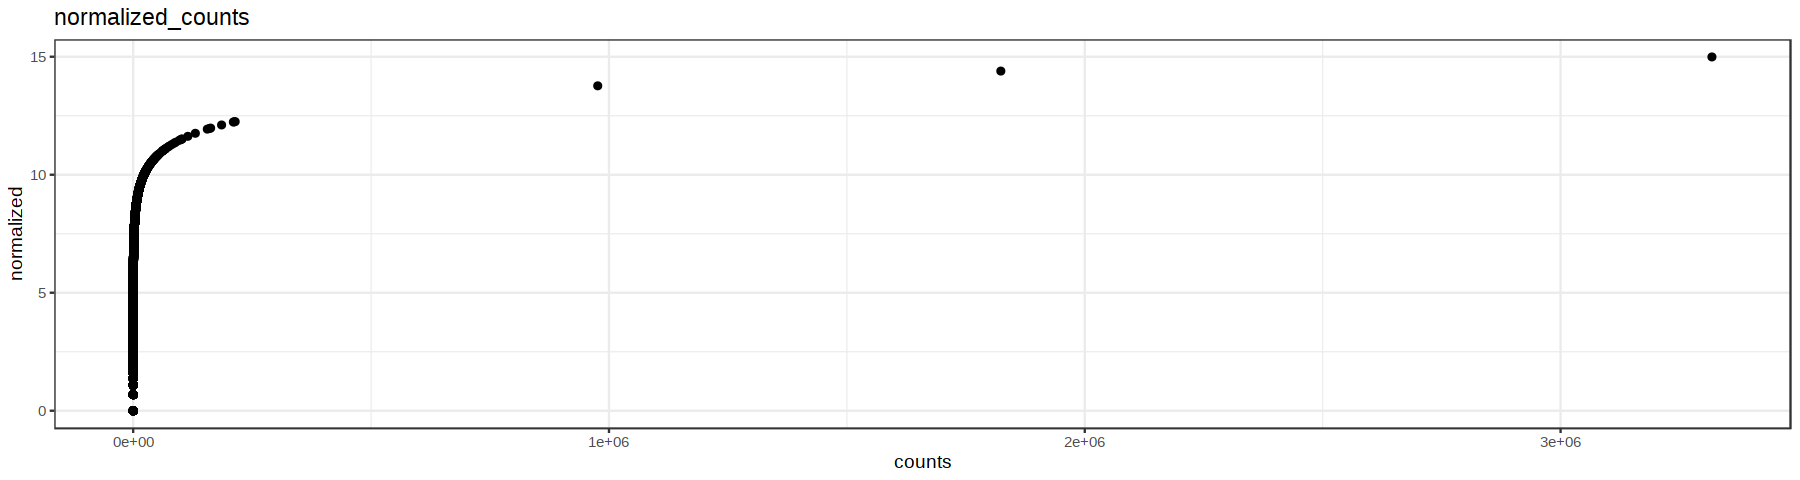

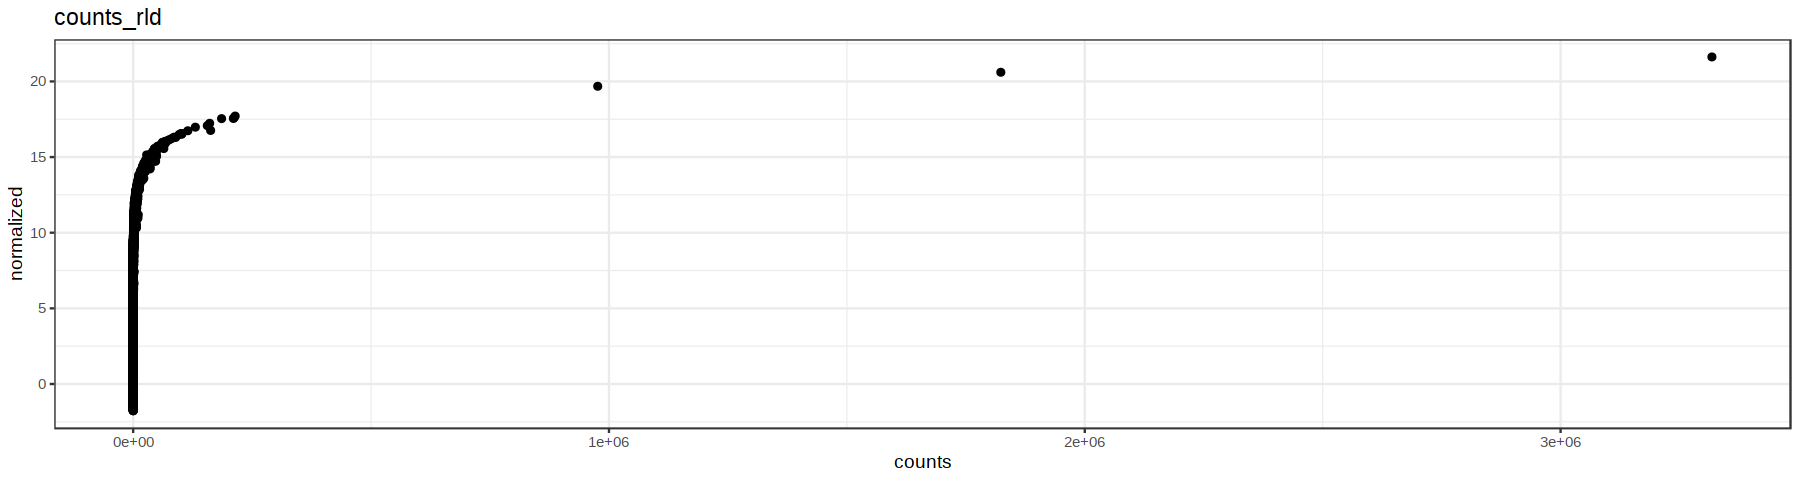

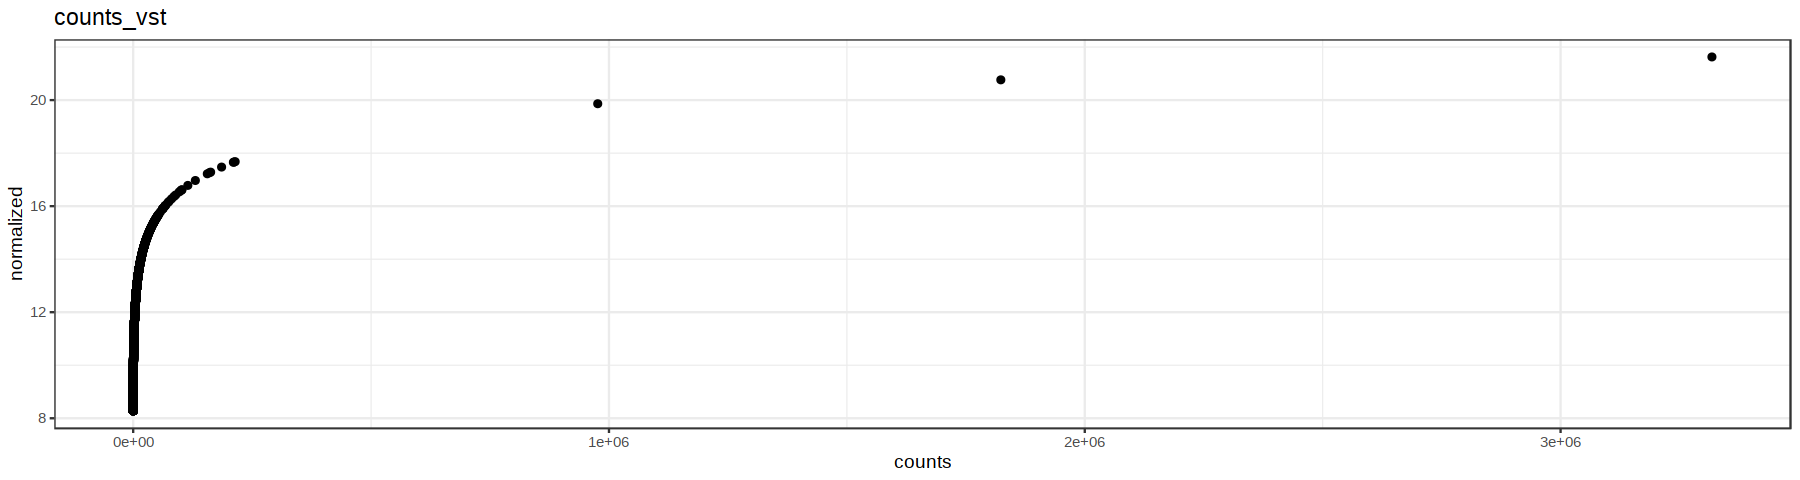

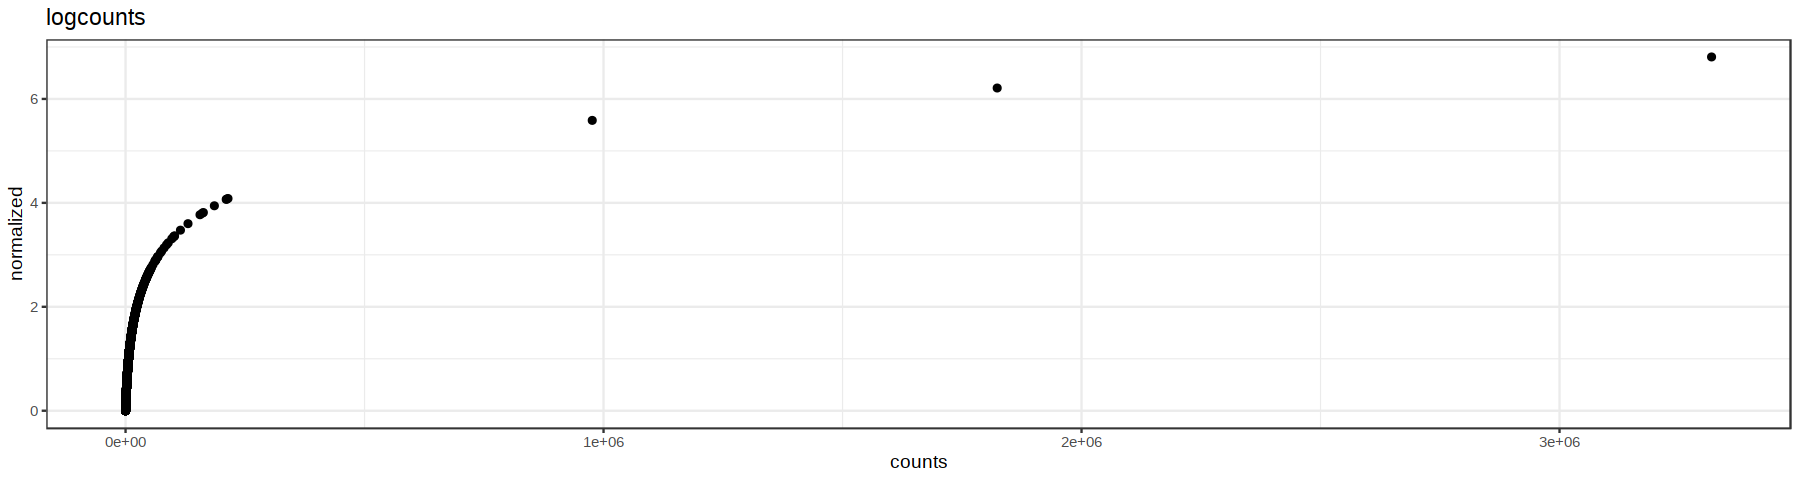

In [107]:
options(repr.plot.width=15, repr.plot.height=4) 
test = cbind(countDataE567[rownames(normalized_counts),][,1], normalized_counts[,1])
colnames(test) = c('counts', 'normalized')
ggplot(as.data.frame(test), aes(counts, normalized)) + geom_point() + theme_bw() + ggtitle('normalized_counts')

test = cbind(countDataE567[rownames(counts_rld),][,1], counts_rld[,1])
colnames(test) = c('counts', 'normalized')
ggplot(as.data.frame(test), aes(counts, normalized)) + geom_point() + theme_bw() + ggtitle('counts_rld')

test = cbind(countDataE567[rownames(counts_vst),][,1], counts_vst[,1])
colnames(test) = c('counts', 'normalized')
ggplot(as.data.frame(test), aes(counts, normalized)) + geom_point() + theme_bw() + ggtitle('counts_vst')

test = cbind(countDataE567[,1], logcounts[,1])
colnames(test) = c('counts', 'normalized')
ggplot(as.data.frame(test), aes(counts, normalized)) + geom_point() + theme_bw() + ggtitle('logcounts')


I like the seurat normalization (logcounts), but maybe the difference isn't too crazy

In [66]:
# continue with own normalization: 
normalized_counts = logcounts

# Inspect QC stats

In [67]:
nrow(normalized_counts)

[1] 47643

In [79]:
head(normalized_counts)

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_3,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Xkr4,0.005975441,0.002177112,0.003630322,0.001551786,0.001502577,0.016733874,0.008067207,0.04550179,0,0.030448197,⋯,0.0548815544,0.078745756,0.050645800,0.037780484,0.063211037,0.100363651,0.037614302,0.066679578,0.05337022,0.066728533
Gm18956,0.000000000,0.001742069,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.00000000,0,0.000000000,⋯,0.0004800165,0.001058869,0.000000000,0.002277202,0.000000000,0.000000000,0.001110417,0.001935006,0.00000000,0.000000000
Gm37686,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.00000000,0,0.001287358,⋯,0.0000000000,0.009489695,0.001549552,0.001771605,0.001150837,0.003345916,0.003050685,0.000000000,0.00000000,0.001149426
Gm1992,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.00000000,0,0.000000000,⋯,0.0000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.00000000,0.000000000
Gm37329,0.000000000,0.002177112,0.003630322,0.005163284,0.000000000,0.000000000,0.000000000,0.00000000,0,0.000000000,⋯,0.0023977817,0.003173248,0.005027289,0.004801360,0.003448545,0.000000000,0.006368126,0.003094215,0.00592675,0.000000000
Gm38148,0.000000000,0.008247931,0.007575699,0.002843104,0.000000000,0.002457866,0.009948582,0.00000000,0,0.010571466,⋯,0.0014393588,0.017503081,0.018057329,0.022046529,0.009550079,0.014308678,0.002219603,0.013849188,0.02059174,0.034291258


In [80]:
head(countData)

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_WT_8,E7.5_WT_9,ex5.5_Stat3null_1,ex5.5_Stat3null_2,ex5.5_Stat3null_3,ex5.5_Stat3null_4,ex5.5_WT_1,ex5.5_WT_2,ex5.5_WT_3,ex5.5_WT_4
Xkr4,22,5,11,6,4,48,64,203,0,96,⋯,166,180,32,50,162,55,47,97,44,99
Gm18956,0,4,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Gm37686,0,0,0,0,0,0,0,0,0,4,⋯,0,3,15,3,12,0,0,2,0,0
Gm1992,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Gm37329,0,5,11,20,0,0,0,0,0,0,⋯,18,0,17,3,22,0,17,32,5,31
Gm38148,0,19,23,11,0,7,79,0,0,33,⋯,63,91,19,31,125,44,37,72,17,162


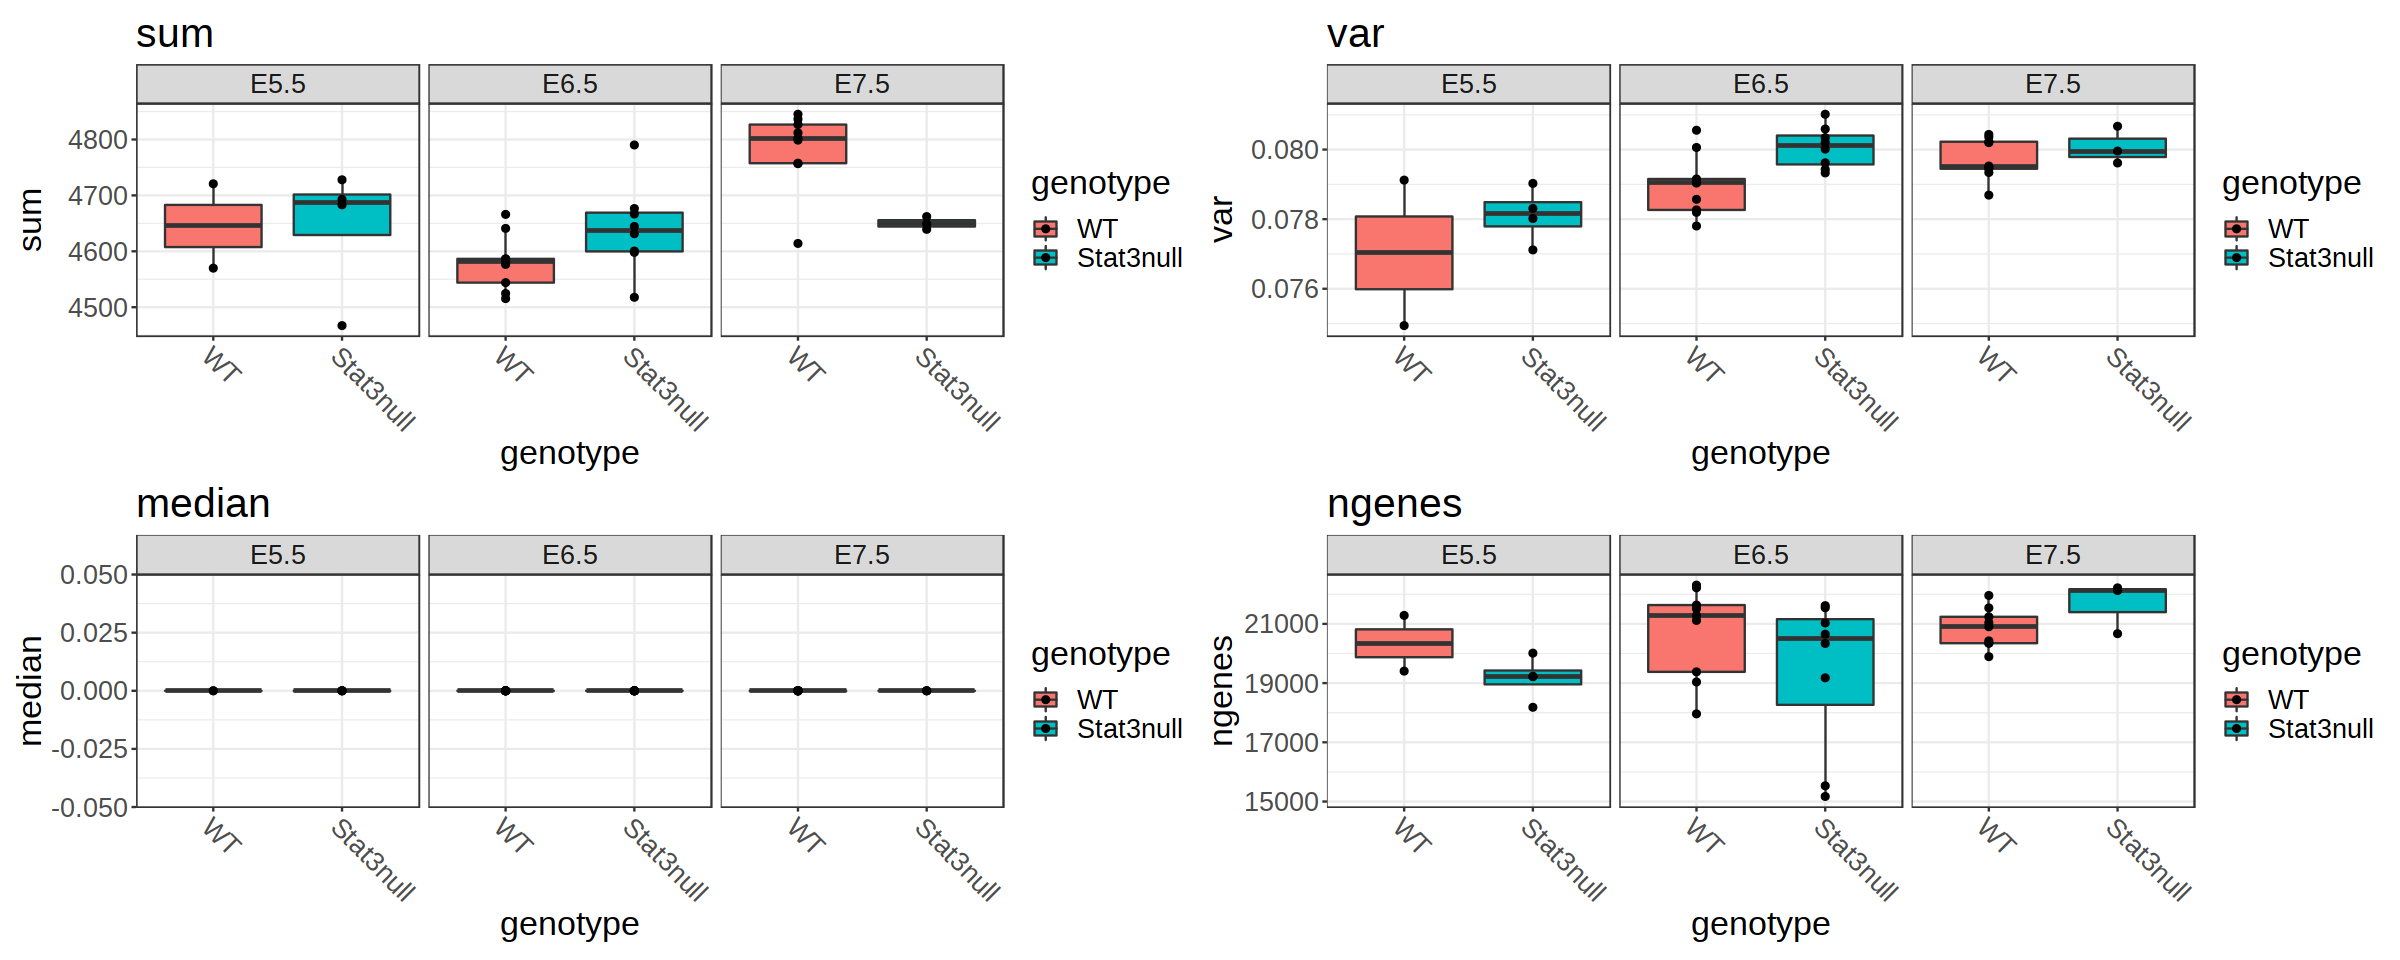

In [68]:
# sample statistics
sample = data.table(sample=colnames(normalized_counts), 
                   sum = colSums(normalized_counts), 
                   mean = colMeans(normalized_counts), 
                   median = colMedians(normalized_counts), 
                   var = colVars(normalized_counts),
                   ngenes = colSums(as.matrix((normalized_counts > 0) + 0)))

meta_sample = merge(colData, sample, by.x=0, by.y='sample')

plot_stat = function(x){
    ggplot(meta_sample, aes_string('genotype', x, fill='genotype')) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_point() + 
        viridis::scale_color_viridis() + 
        facet_wrap(~stage) + 
        ggtitle(x) +
        theme_bw() + 
        theme(text=element_text(size=20), 
                   axis.text.x=element_text(angle=-45, hjust=0, vjust=1))
    }
options(repr.plot.width=20, repr.plot.height=8)
plot_stat('sum') + plot_stat('var') + plot_stat('median') + plot_stat('ngenes')
options(repr.plot.width=10, repr.plot.height=8)

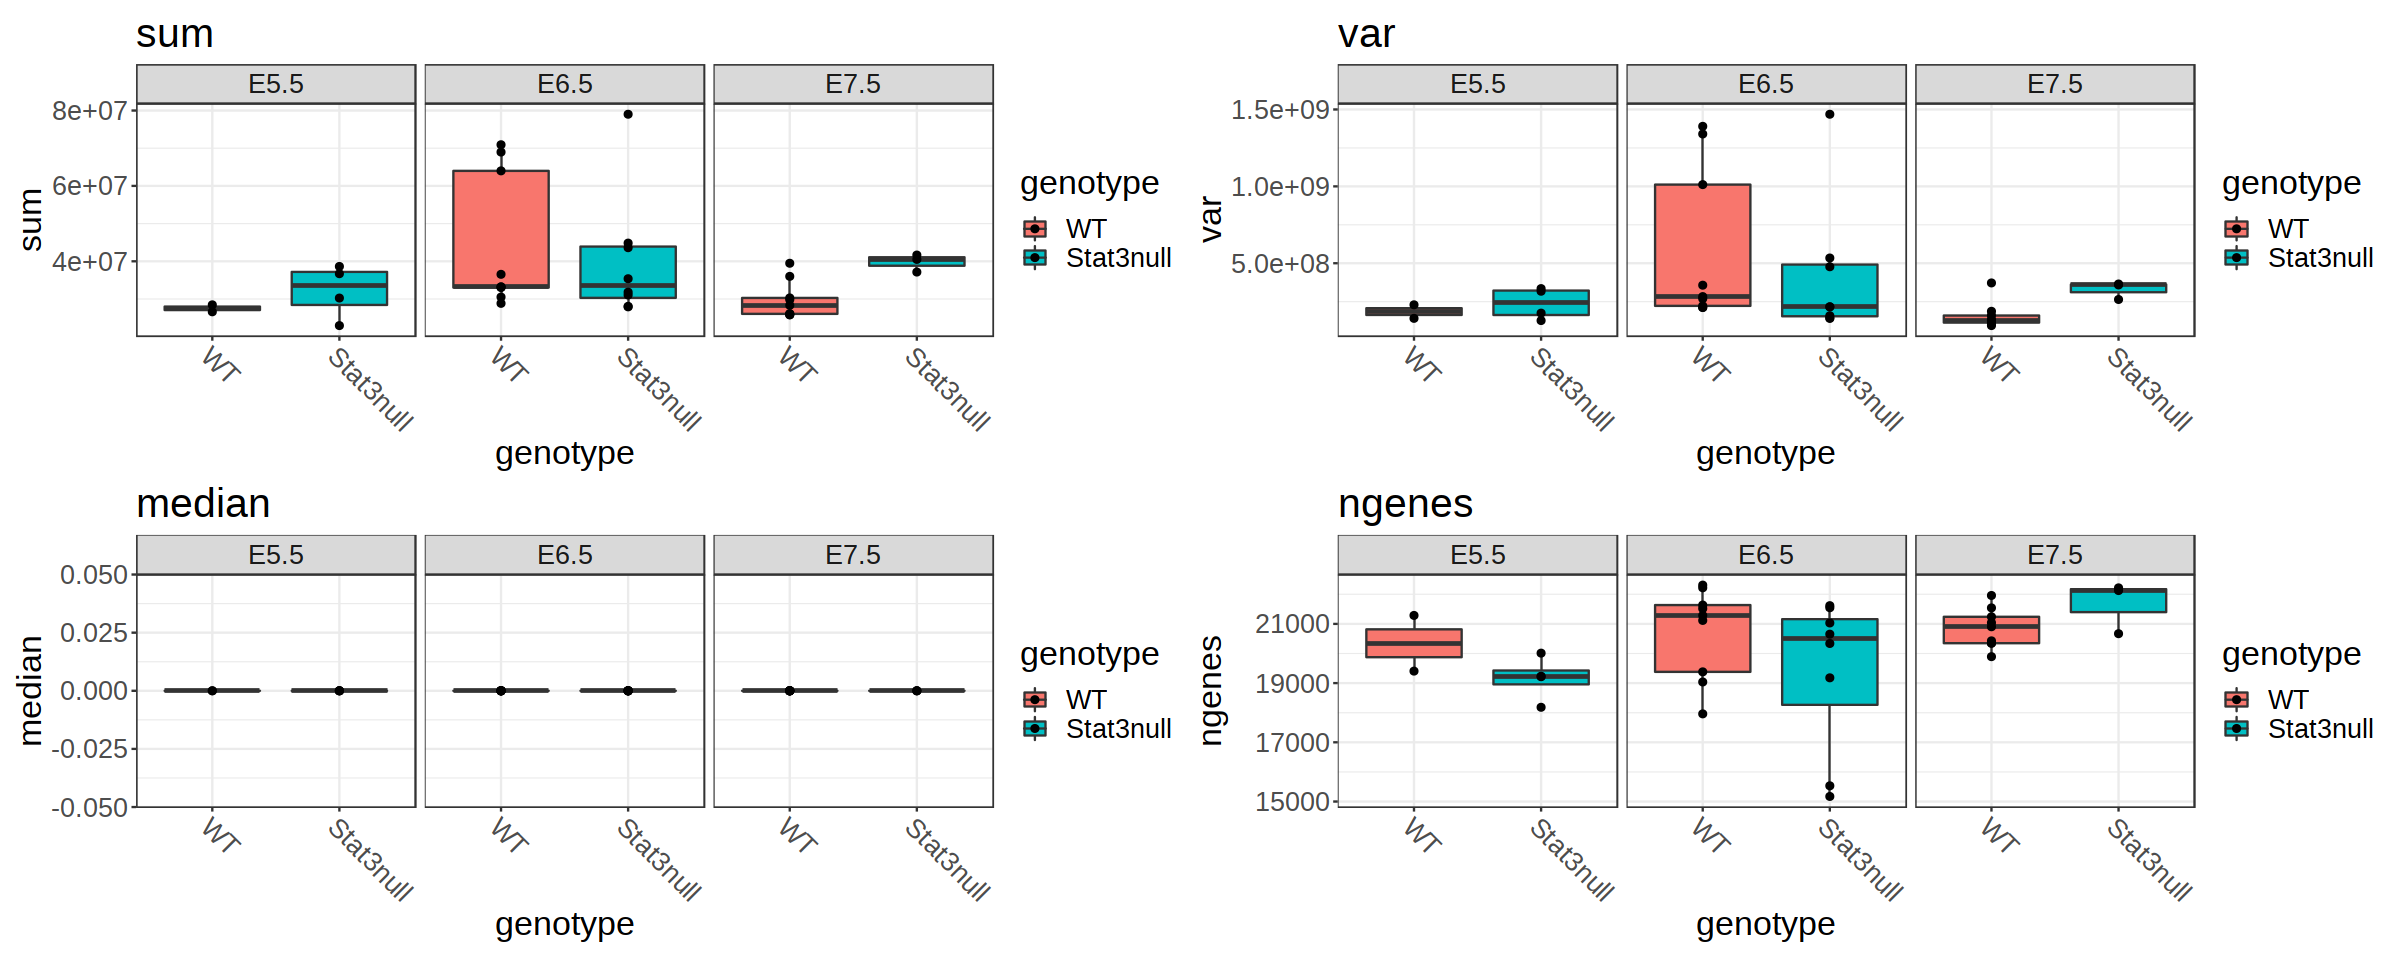

In [69]:
# sample statistics
sample = data.table(sample=colnames(countData), 
                   sum = colSums(countData), 
                   mean = colMeans(countData), 
                   median = colMedians(countData), 
                   var = colVars(countData),
                   ngenes = colSums(as.matrix((countData > 0) + 0)))

meta_sample = merge(colData, sample, by.x=0, by.y='sample')

plot_stat = function(x){
    ggplot(meta_sample, aes_string('genotype', x, fill='genotype')) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_point() + 
        viridis::scale_color_viridis() + 
        facet_wrap(~stage) + 
        ggtitle(x) +
        theme_bw() + 
        theme(text=element_text(size=20), 
                   axis.text.x=element_text(angle=-45, hjust=0, vjust=1))
    }
options(repr.plot.width=20, repr.plot.height=8)
plot_stat('sum') + plot_stat('var') + plot_stat('median') + plot_stat('ngenes')
options(repr.plot.width=10, repr.plot.height=8)

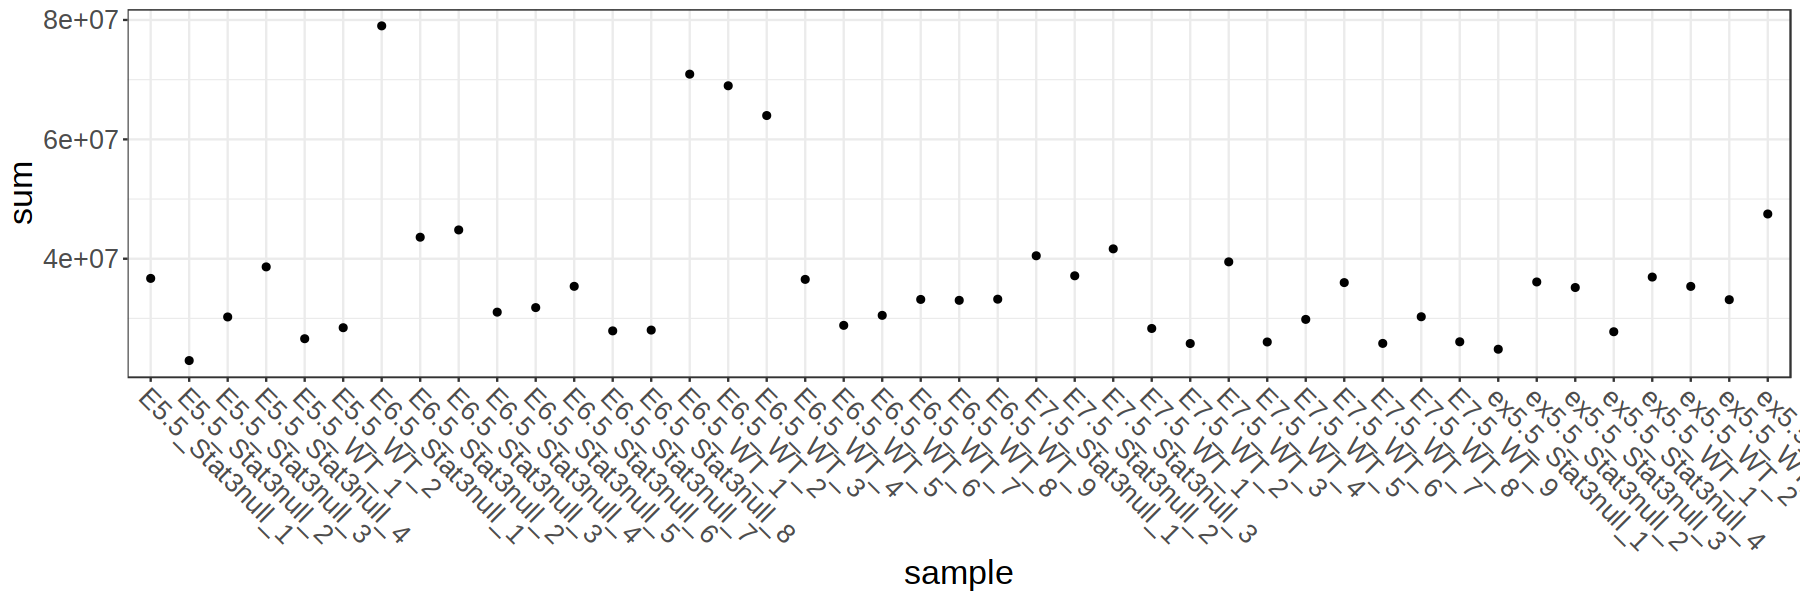

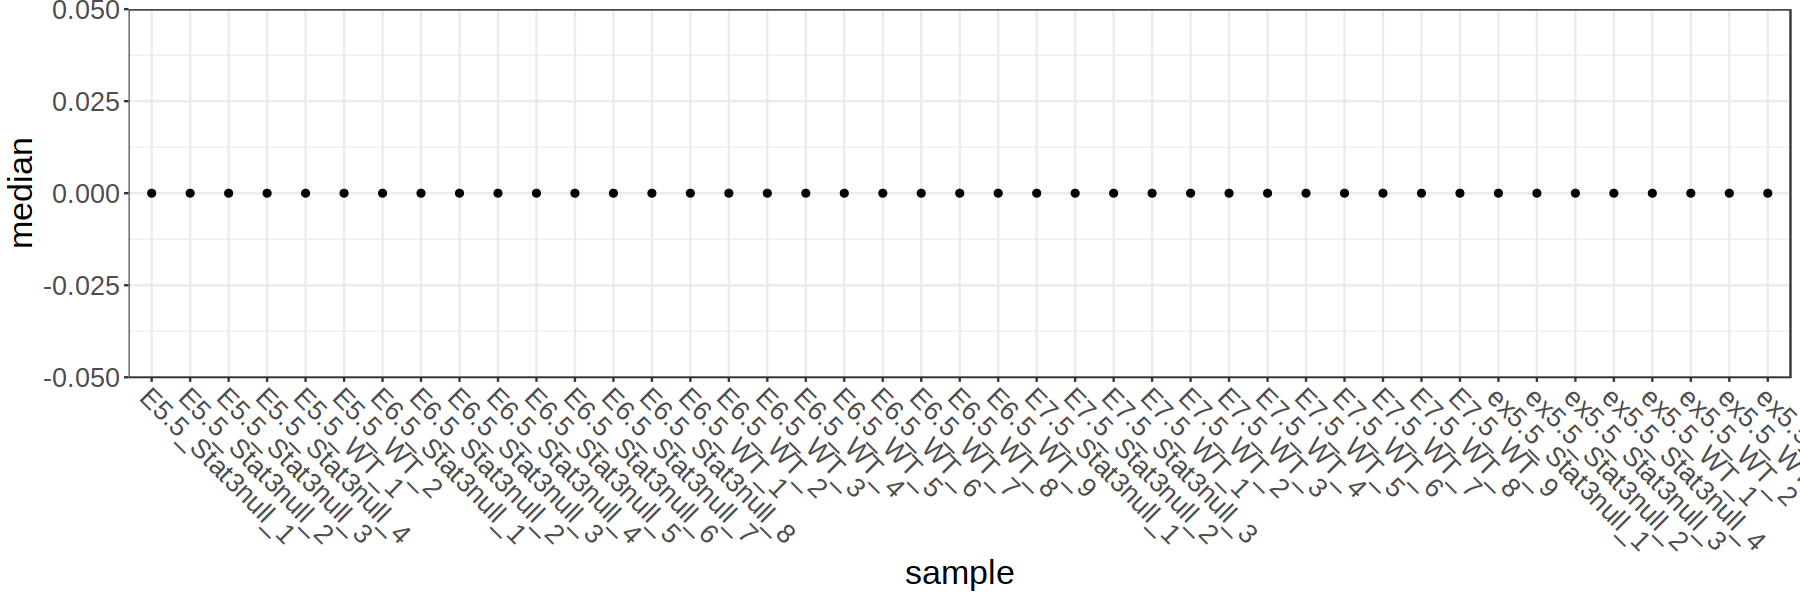

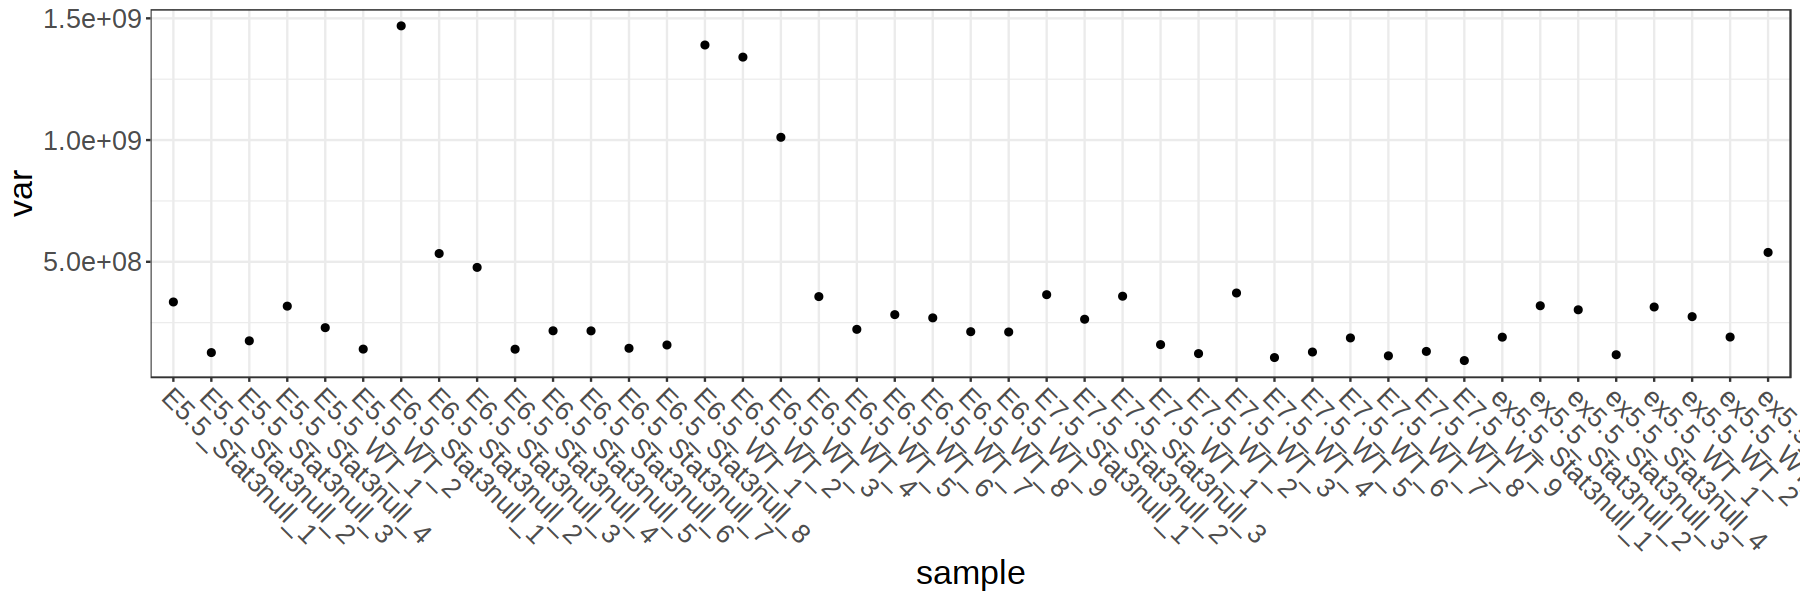

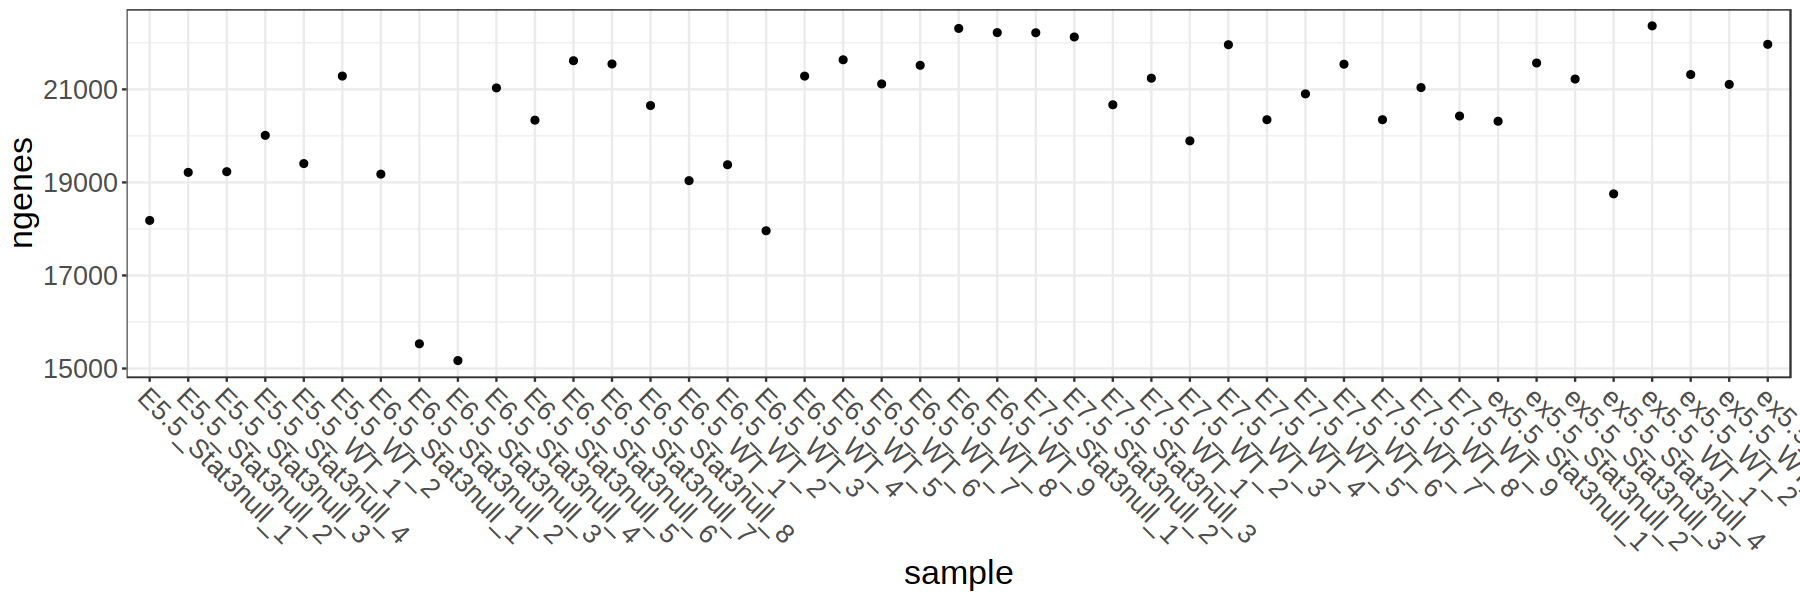

In [70]:
options(repr.plot.width=15, repr.plot.height=5) 
ggplot(sample, aes(sample, sum)) + geom_point() + theme_bw() + theme(axis.text.x=element_text(angle=-45, hjust=0, vjust=1), text=element_text(size=20))
ggplot(sample, aes(sample, median)) + geom_point() + theme_bw() + theme(axis.text.x=element_text(angle=-45, hjust=0, vjust=1), text=element_text(size=20))
ggplot(sample, aes(sample, var)) + geom_point() + theme_bw() + theme(axis.text.x=element_text(angle=-45, hjust=0, vjust=1), text=element_text(size=20))
ggplot(sample, aes(sample, ngenes)) + geom_point() + theme_bw() + theme(axis.text.x=element_text(angle=-45, hjust=0, vjust=1), text=element_text(size=20))

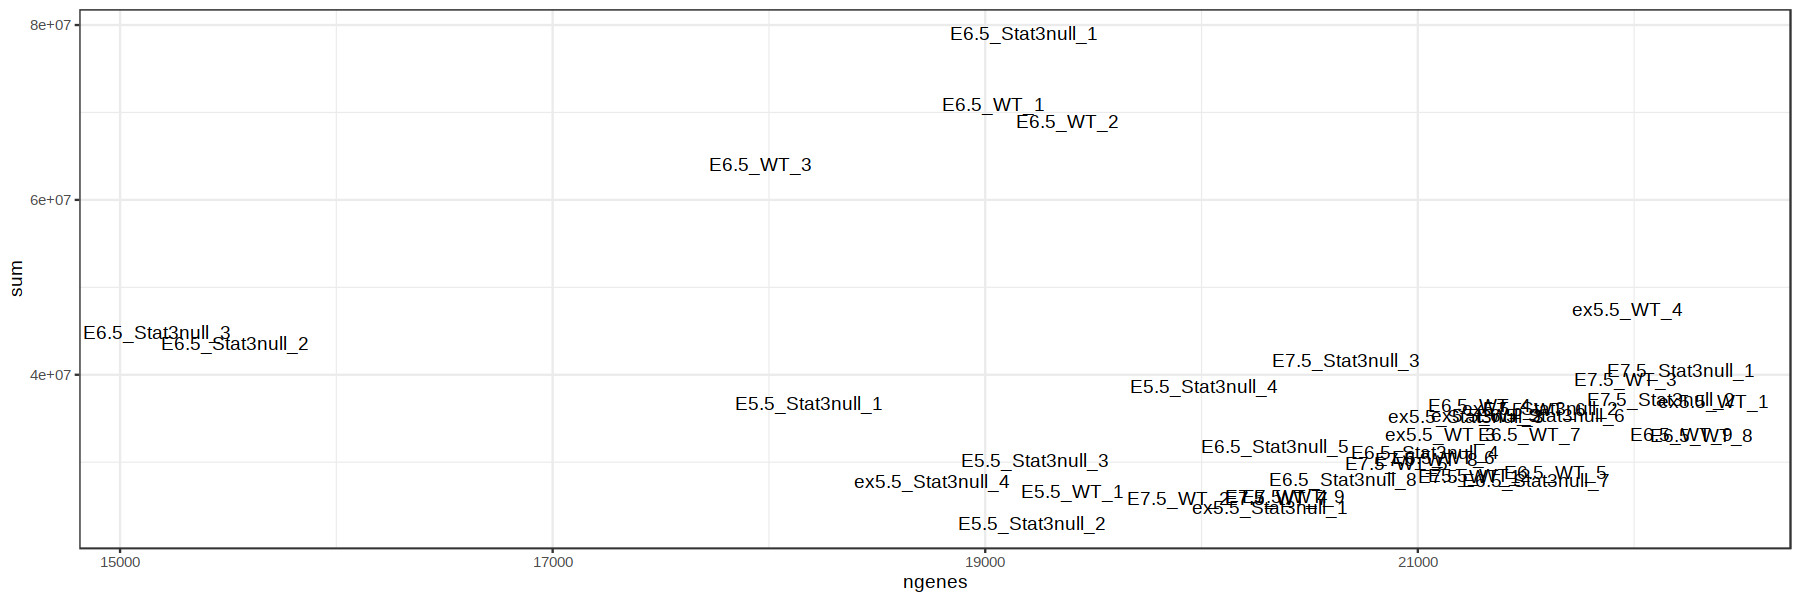

In [71]:
 ggplot(sample, aes(ngenes, sum, label=sample)) + geom_text() + theme_bw()

Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 1 has 35 rows but longest item has 43; recycled with remainder.”


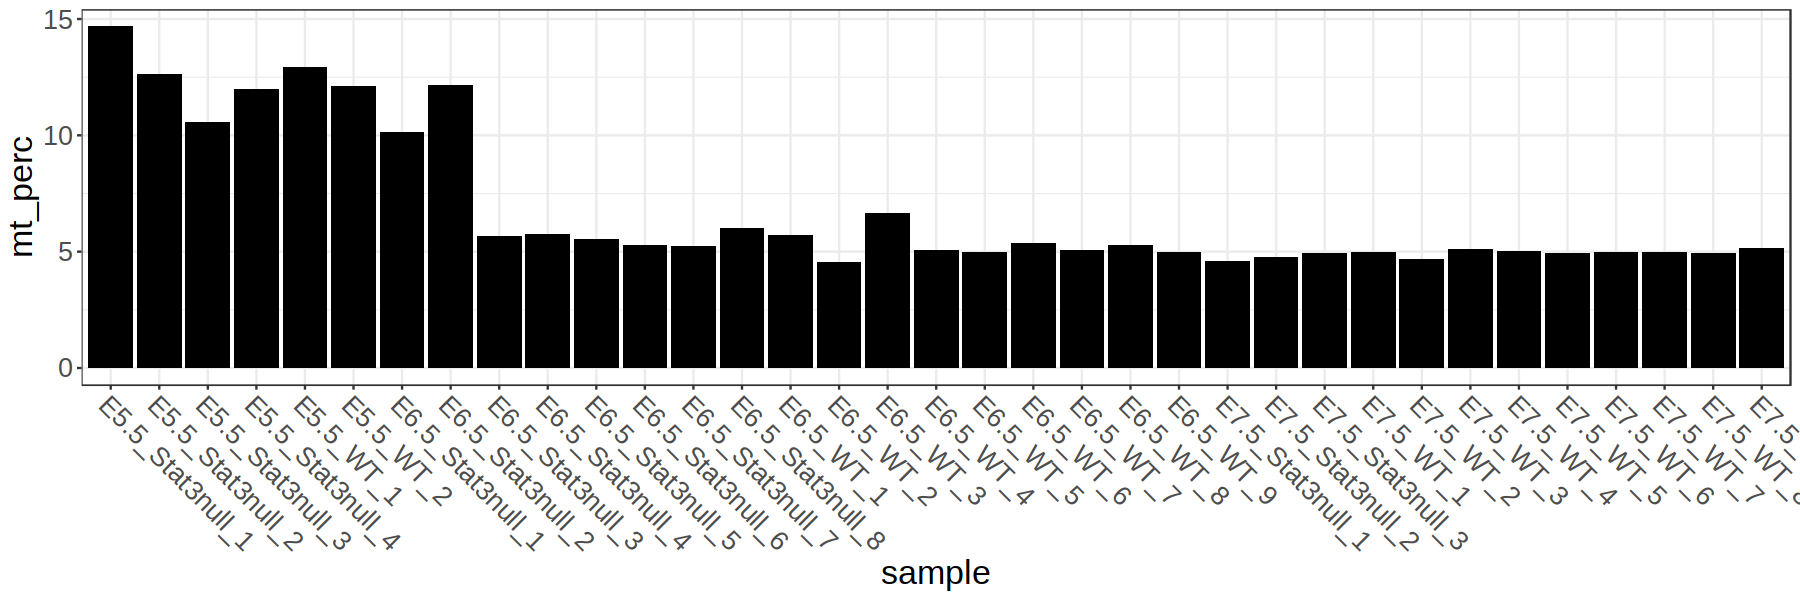

In [72]:
options(repr.plot.width=15, repr.plot.height=5) 
mt_stats = data.table(sample=colnames(normalized_counts),
                      mt_expr = colSums(countData[grep('^mt', rownames(countData)),]),
                        total_expr = colSums(countData)) %>%
                    .[,mt_perc:=round(mt_expr/total_expr*100,2)]

ggplot(mt_stats, aes(sample, mt_perc)) + geom_bar(stat='identity', fill='black') + theme_bw() + theme(text=element_text(size=20), axis.text.x=element_text(angle=-45, hjust=0, vjust=1))

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



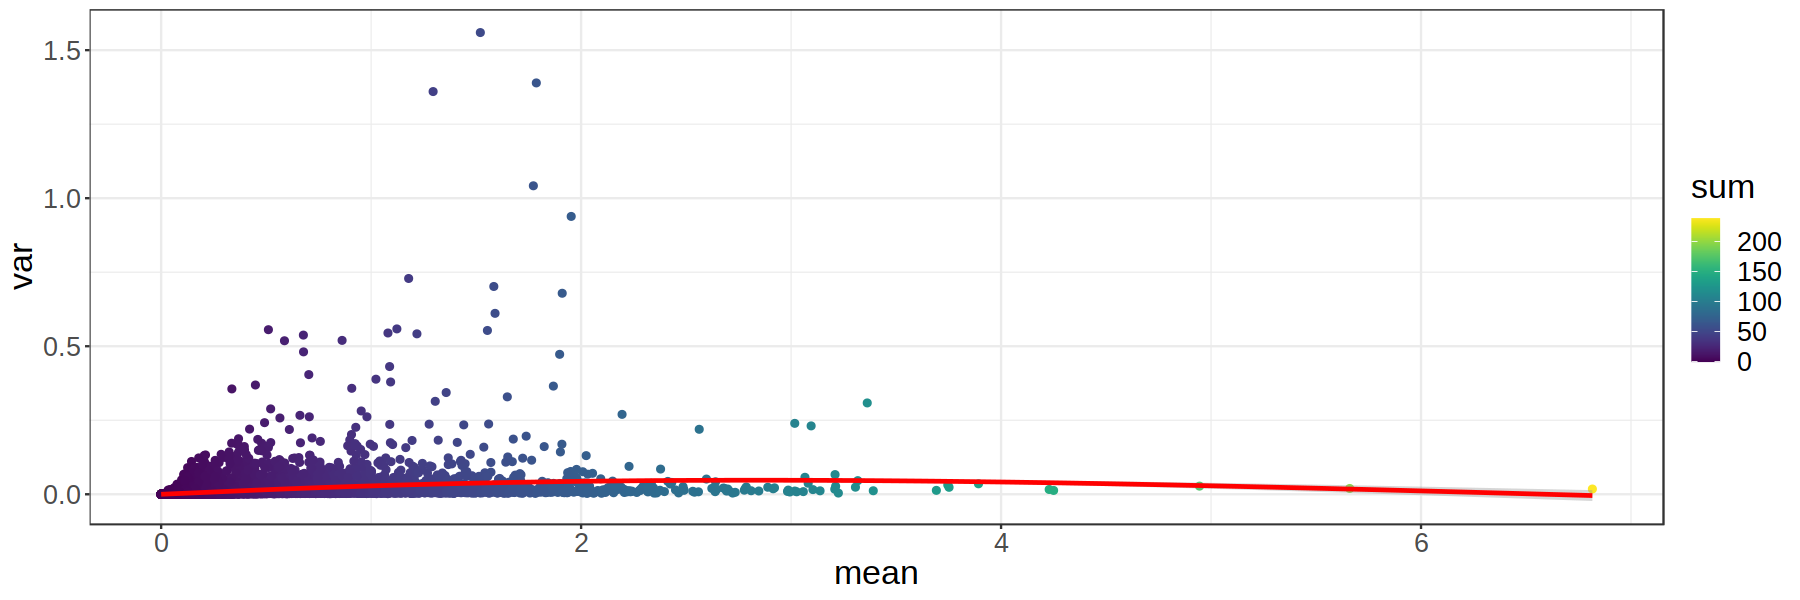

In [73]:
# Gene statistics
genes = data.table(gene=rownames(normalized_counts), 
                   sum = rowSums(normalized_counts), 
                   mean = rowMeans(normalized_counts), 
                   var = rowVars(normalized_counts))

ggplot(genes, aes(mean, var, col=sum)) + 
    geom_point() + 
    geom_smooth(col='red') + 
    viridis::scale_color_viridis() + 
    theme_bw() + theme(text=element_text(size=20))

In [74]:
head(genes)

gene,sum,mean,var
<chr>,<dbl>,<dbl>,<dbl>
Xkr4,1.206645108,0.0344755745,6.323622e-04
Gm18956,0.009410932,0.0002688838,3.726682e-07
Gm37686,0.053767325,0.0015362093,4.736654e-06
Gm1992,0.000000000,0.0000000000,0.000000e+00
Gm37329,0.115516691,0.0033004769,1.295943e-05
Gm38148,0.478398364,0.0136685247,1.839021e-04


In [75]:
genes.long = genes %>% melt(id.vars = 'gene', variable.name = "stat", value.name = 'value')

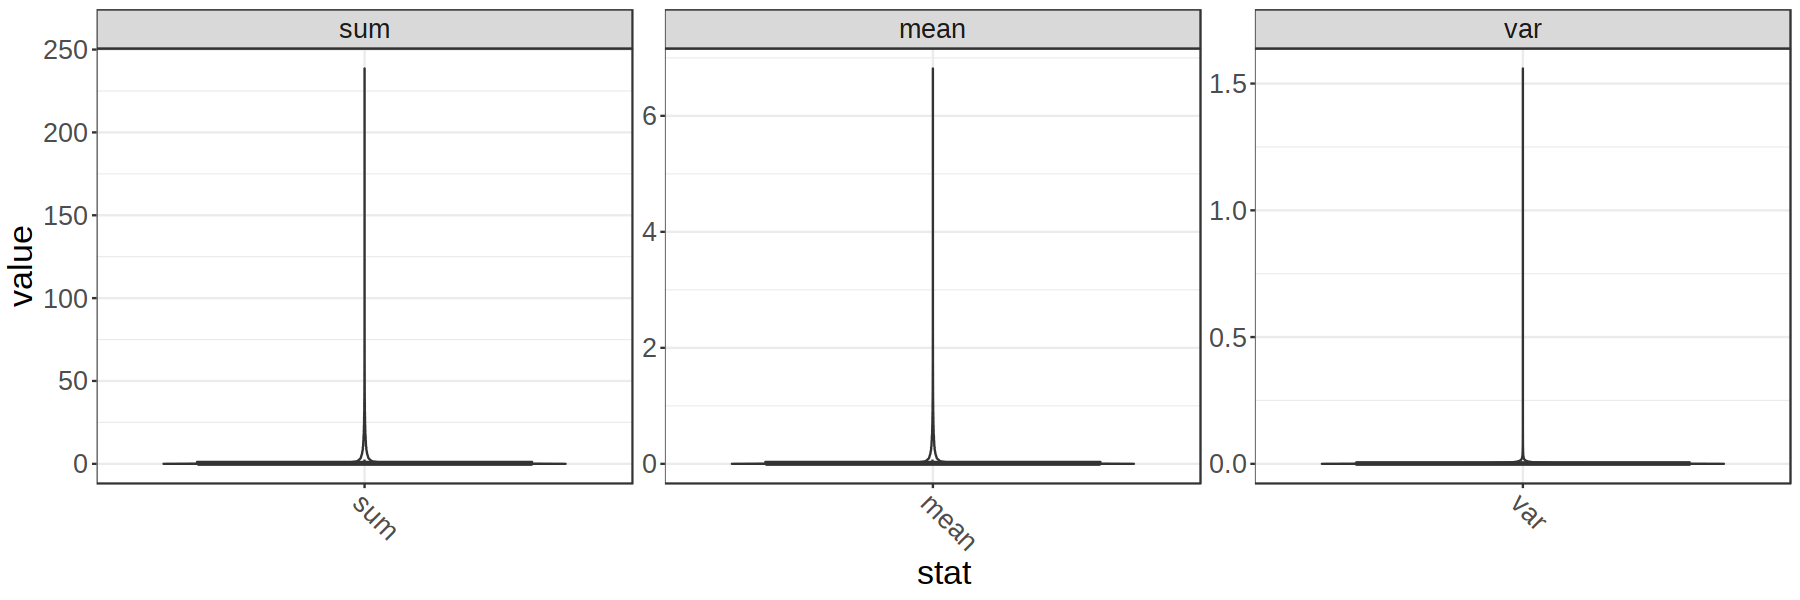

In [76]:
   ggplot(genes.long, aes(stat,value)) + 
geom_violin() +         
geom_boxplot(outlier.shape = NA) + 
  #      geom_point() + 
        facet_wrap(~stat, scales='free') +
        theme_bw() + 
        theme(text=element_text(size=20), 
                   axis.text.x=element_text(angle=-45, hjust=0, vjust=1))

In [77]:
head(genes)

gene,sum,mean,var
<chr>,<dbl>,<dbl>,<dbl>
Xkr4,1.206645108,0.0344755745,6.323622e-04
Gm18956,0.009410932,0.0002688838,3.726682e-07
Gm37686,0.053767325,0.0015362093,4.736654e-06
Gm1992,0.000000000,0.0000000000,0.000000e+00
Gm37329,0.115516691,0.0033004769,1.295943e-05
Gm38148,0.478398364,0.0136685247,1.839021e-04


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



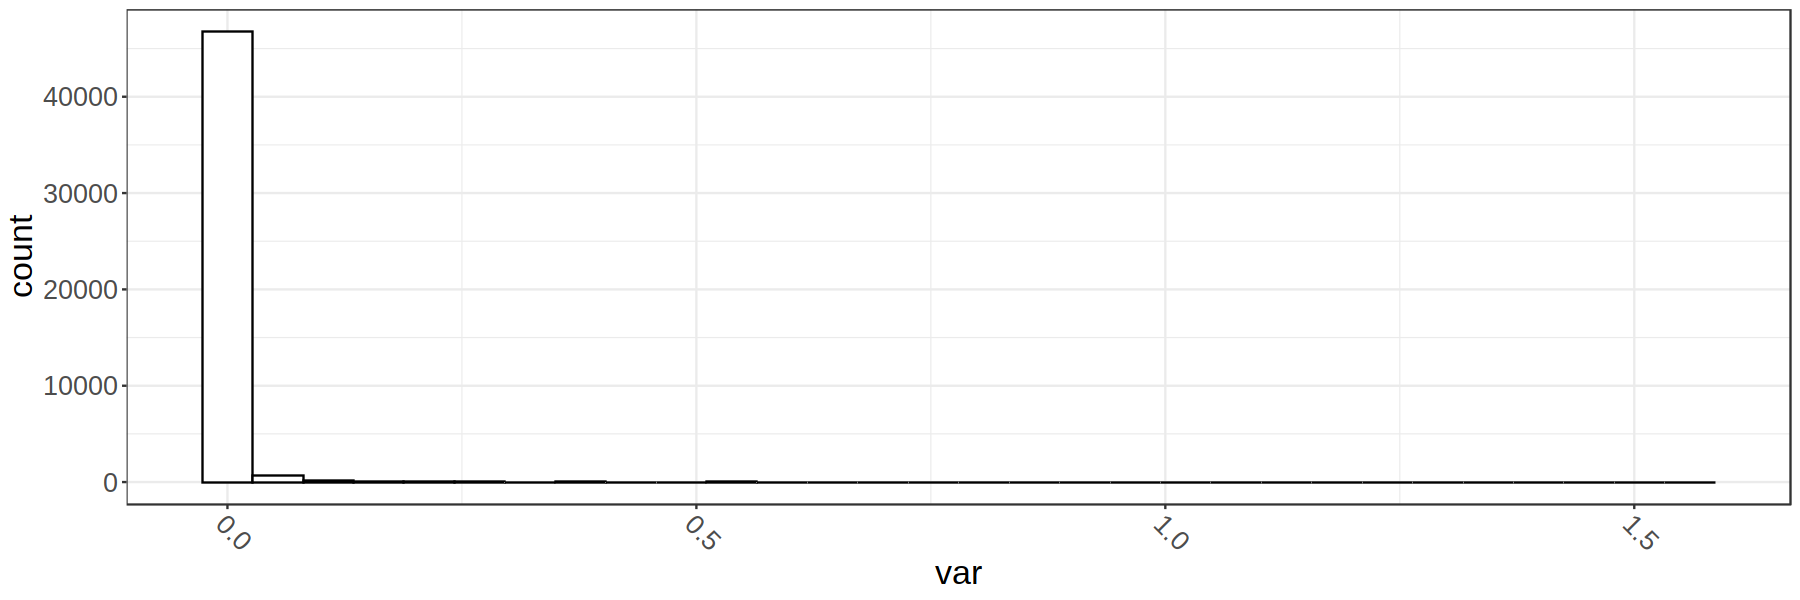

In [78]:
ggplot(genes, aes(var)) + 
    geom_histogram(col='black', fill='white') + 
    theme_bw() + 
    theme(text=element_text(size=20), 
        axis.text.x=element_text(angle=-45, hjust=0, vjust=1))

In [35]:
#Heatmap of the sample-to-sample distances
#removing genes that are not variable across any of the samples
var_genes = genes[var>0.1, gene]


# Below you can see how the different normalization methods work, I'd stick with the normalized_counts 

In [38]:
top_var = genes[order(-var), ]$gene

In [39]:
head(counts[head(top_var),])

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'head': object of type 'closure' is not subsettable


In [ ]:
head(normalized_counts[head(top_var),])

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_3,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Hist2h2aa1,0.681345,0,0.000000,9.469555,0.000000,0.000000,8.774184,8.109664,7.553875,7.922574,⋯,0.000000,0.000000,0.8325309,0.000000,0.000000,0.7475231,9.691875,0.000000,0.000000,0.000000
Gm20634,3.614473,0,1.935833,9.297511,3.125226,3.585616,9.254332,9.014757,8.821492,8.852840,⋯,2.593925,10.314412,6.9012699,4.680866,4.825399,7.3635838,10.044069,1.819447,0.000000,0.000000
Ddx3y,6.970210,0,0.000000,7.435937,0.000000,0.000000,0.000000,7.696330,7.747014,0.000000,⋯,7.439744,7.371199,7.0593785,7.365493,7.285422,0.0000000,7.416725,0.000000,7.280621,7.548726
Eif2s3y,5.970276,0,0.000000,6.815706,0.000000,0.000000,0.000000,7.631797,7.149944,2.999636,⋯,6.634984,6.861041,6.7893163,6.913084,6.582317,0.0000000,6.508284,0.000000,6.629794,6.461601
T,0.000000,0,0.000000,0.000000,0.000000,2.816817,4.956666,6.958565,0.000000,3.667565,⋯,8.672986,8.983118,8.8318165,5.235345,7.876039,7.9622276,8.116528,8.771825,8.731090,8.950582
Kdr,0.000000,0,0.000000,4.604059,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,⋯,7.197286,6.556566,6.4181861,2.911055,8.207289,8.1830524,7.900712,7.600851,7.898653,6.363524


In [ ]:
head(countDataE567[head(top_var),])

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_3,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Hist2h2aa1,1,0,0,14152,0,0,14200,3942,2355,2602,⋯,0,0,1,0,0,1,17425,0,0,0
Gm20634,37,0,5,11915,16,29,22953,9747,8369,6598,⋯,15,25406,764,123,96,1418,24782,4,0,0
Ddx3y,1089,0,0,1851,0,0,0,2607,2857,0,⋯,2061,1338,895,1818,1132,0,1790,0,1339,1523
Eif2s3y,400,0,0,995,0,0,0,2444,1572,18,⋯,921,803,683,1156,560,0,721,0,698,513
T,0,0,0,0,0,13,310,1246,0,36,⋯,7077,6710,5271,215,2044,2581,3605,4991,5714,6190
Kdr,0,0,0,108,0,0,0,0,0,0,⋯,1617,592,471,20,2847,3219,2905,1547,2485,465


In [ ]:
head(counts_vst[head(top_var),])

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_3,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Hist2h2aa1,8.365052,8.28432,8.284320,13.728610,8.284320,8.284320,12.788302,11.93819,11.28288,11.710979,⋯,8.28432,8.28432,8.377433,8.284320,8.284320,8.370459,14.03637,8.284320,8.28432,8.28432
Gm20634,8.773118,8.28432,8.483129,13.492470,8.664408,8.765987,13.433518,13.10903,12.85092,12.892538,⋯,8.57136,14.90987,10.601307,9.117345,9.178457,11.073409,14.52878,8.469947,8.28432,8.28432
Ddx3y,10.668217,8.28432,8.284320,11.152074,8.284320,8.284320,8.284320,11.44498,11.50368,8.284320,⋯,11.15625,11.08163,10.756616,11.075469,10.989829,8.284320,11.13107,8.284320,10.98474,11.27711
Eif2s3y,9.824925,8.28432,8.284320,10.520028,8.284320,8.284320,8.284320,11.37101,10.84851,8.640302,⋯,10.35489,10.56285,10.495359,10.612683,10.308446,8.284320,10.24446,8.284320,10.35028,10.20489
T,8.284320,8.28432,8.284320,8.284320,8.284320,8.607636,9.237516,10.65683,8.28432,8.786493,⋯,12.65517,13.06653,12.864615,9.374881,11.655450,11.758615,11.94664,12.785186,12.73147,13.02293
Kdr,8.284320,8.28432,8.284320,9.086467,8.284320,8.284320,8.284320,8.28432,8.28432,8.284320,⋯,10.89737,10.28602,10.168639,8.624128,12.059121,12.028955,11.68484,11.335852,11.68238,10.12374


In [37]:
head(logcount[head(top_var),])

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'head': object 'logcount' not found


# plotting correlation and distance

color scale is a bit strange, everything that's red is already above 0.85 correlation

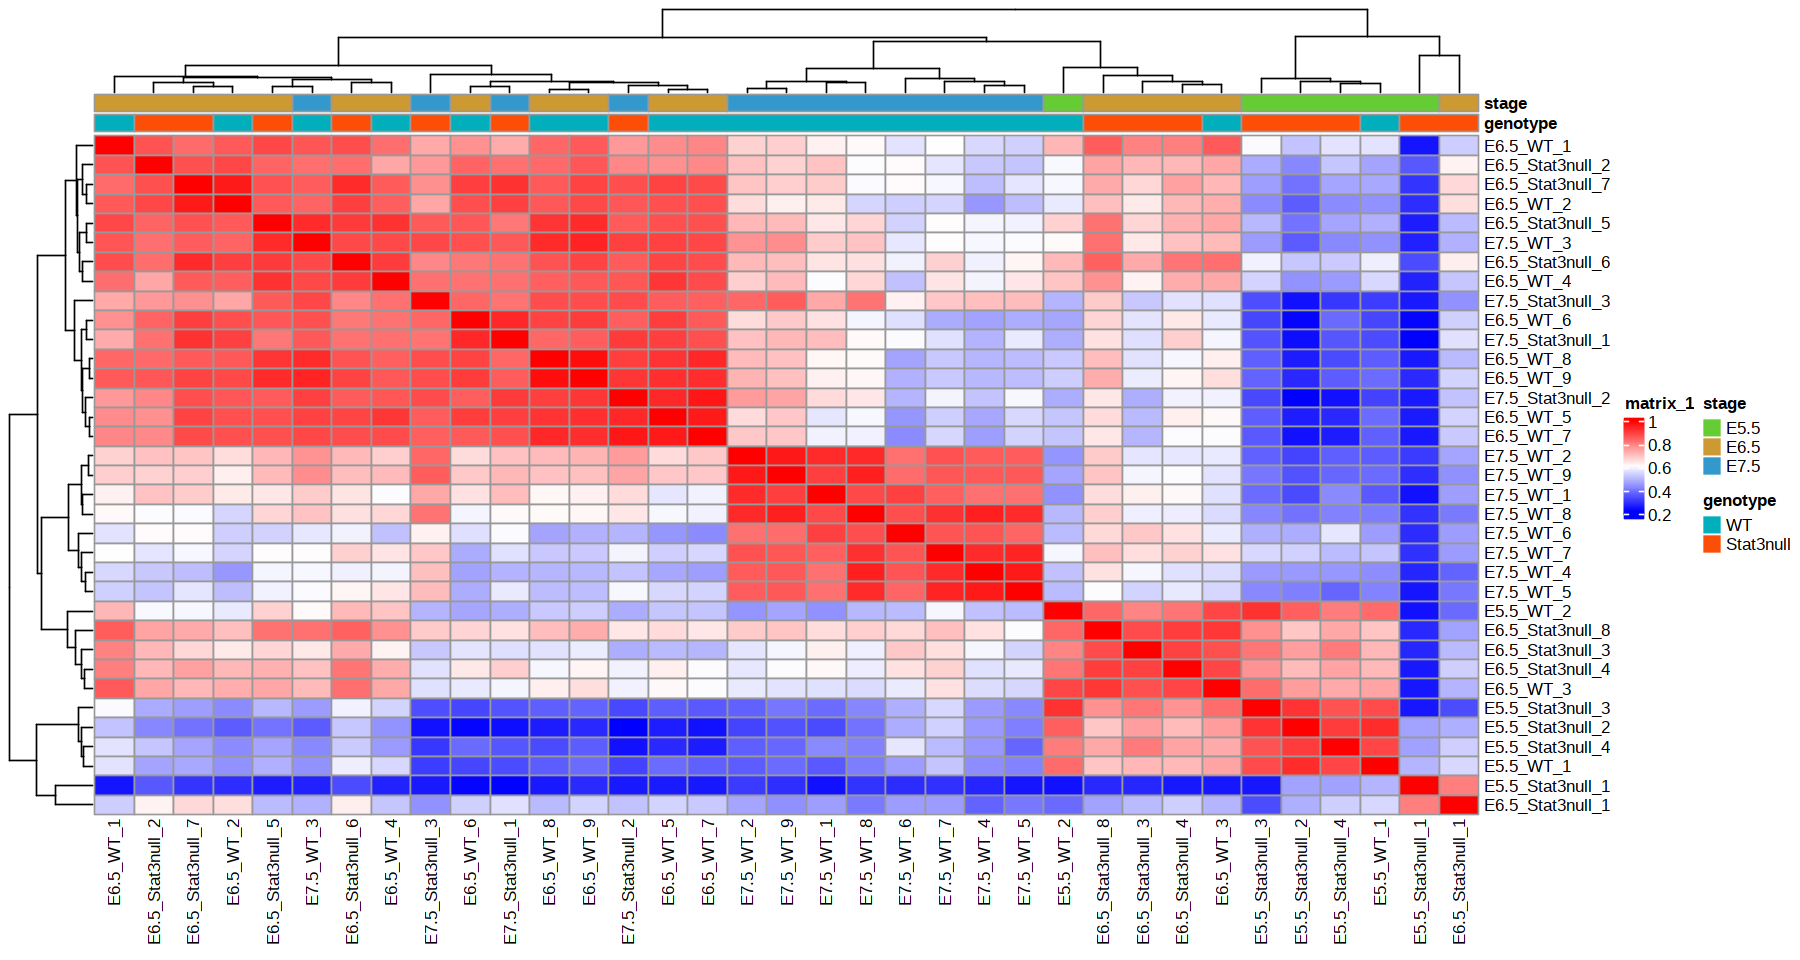

In [40]:
counts_cor = cor(normalized_counts[var_genes,])

colors <- colorRampPalette(c("blue","white","red"))(99)
annocolors <- list(
  genotype = c("WT"="#00afbb", "Stat3null"="#fc4e07"),
  stage = c("E5.5"="#66cc33", "E6.5"="#cc9933", "E7.5"="#3399cc")
)
colData$genotype <- factor(colData$genotype, levels = c("WT", "Stat3null"))

options(repr.plot.width=15, repr.plot.height=8) 
pheatmap(counts_cor,
         annotation_col = colData[,c('genotype', 'stage')],
         annotation_colors = annocolors,
         col=colors)

In [41]:
counts_dist <- dist(t(normalized_counts[var_genes,]), method = "euclidean")
counts_dist = as.matrix(counts_dist)

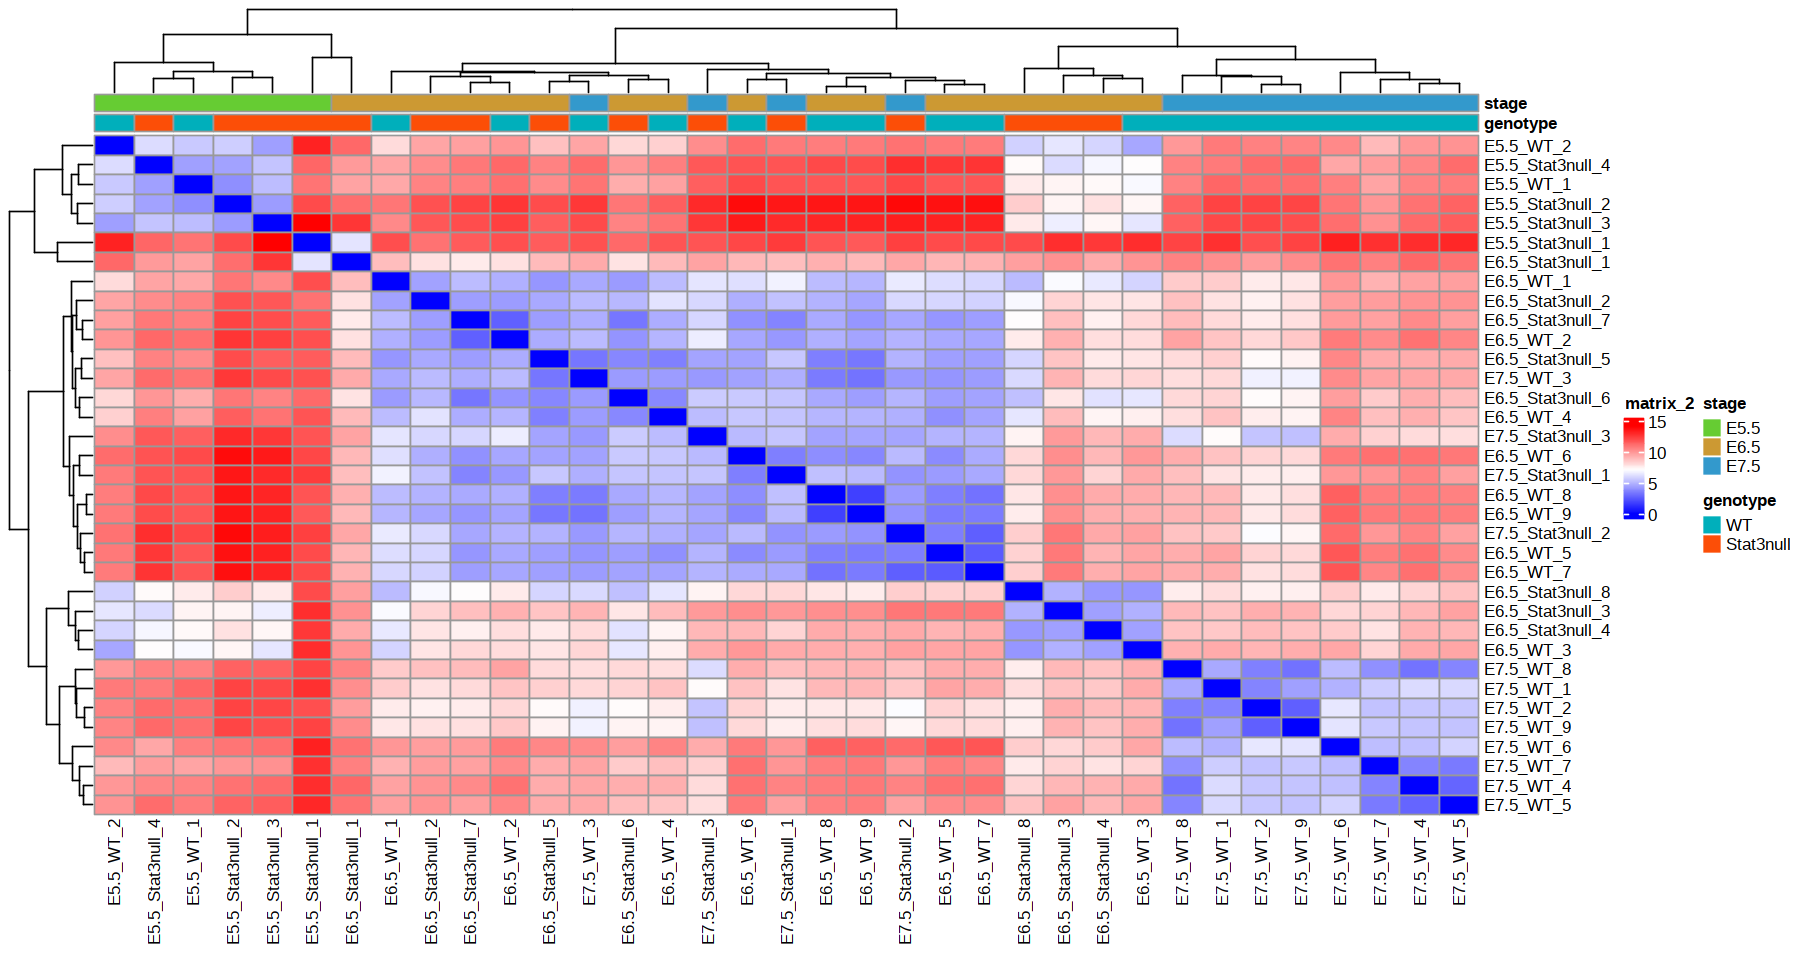

In [42]:
colors <- colorRampPalette(c("blue","white","red"))(99)
annocolors <- list(
  genotype = c("WT"="#00afbb", "Stat3null"="#fc4e07"),
  stage = c("E5.5"="#66cc33", "E6.5"="#cc9933", "E7.5"="#3399cc")
)
colData$genotype <- factor(colData$genotype, levels = c("WT", "Stat3null"))

options(repr.plot.width=15, repr.plot.height=8) 
pheatmap(counts_dist,
         annotation_col = colData[,c('genotype', 'stage')],
         annotation_colors = annocolors,
         col=colors)

# Plotting PCAs

## the PCA 3 vs 4 plot shows most clearly which samples are big outliers:
E5.5 stat3 1
E6.5 stat3 1
E6.5 stat3 2
E6.5 stat3 3

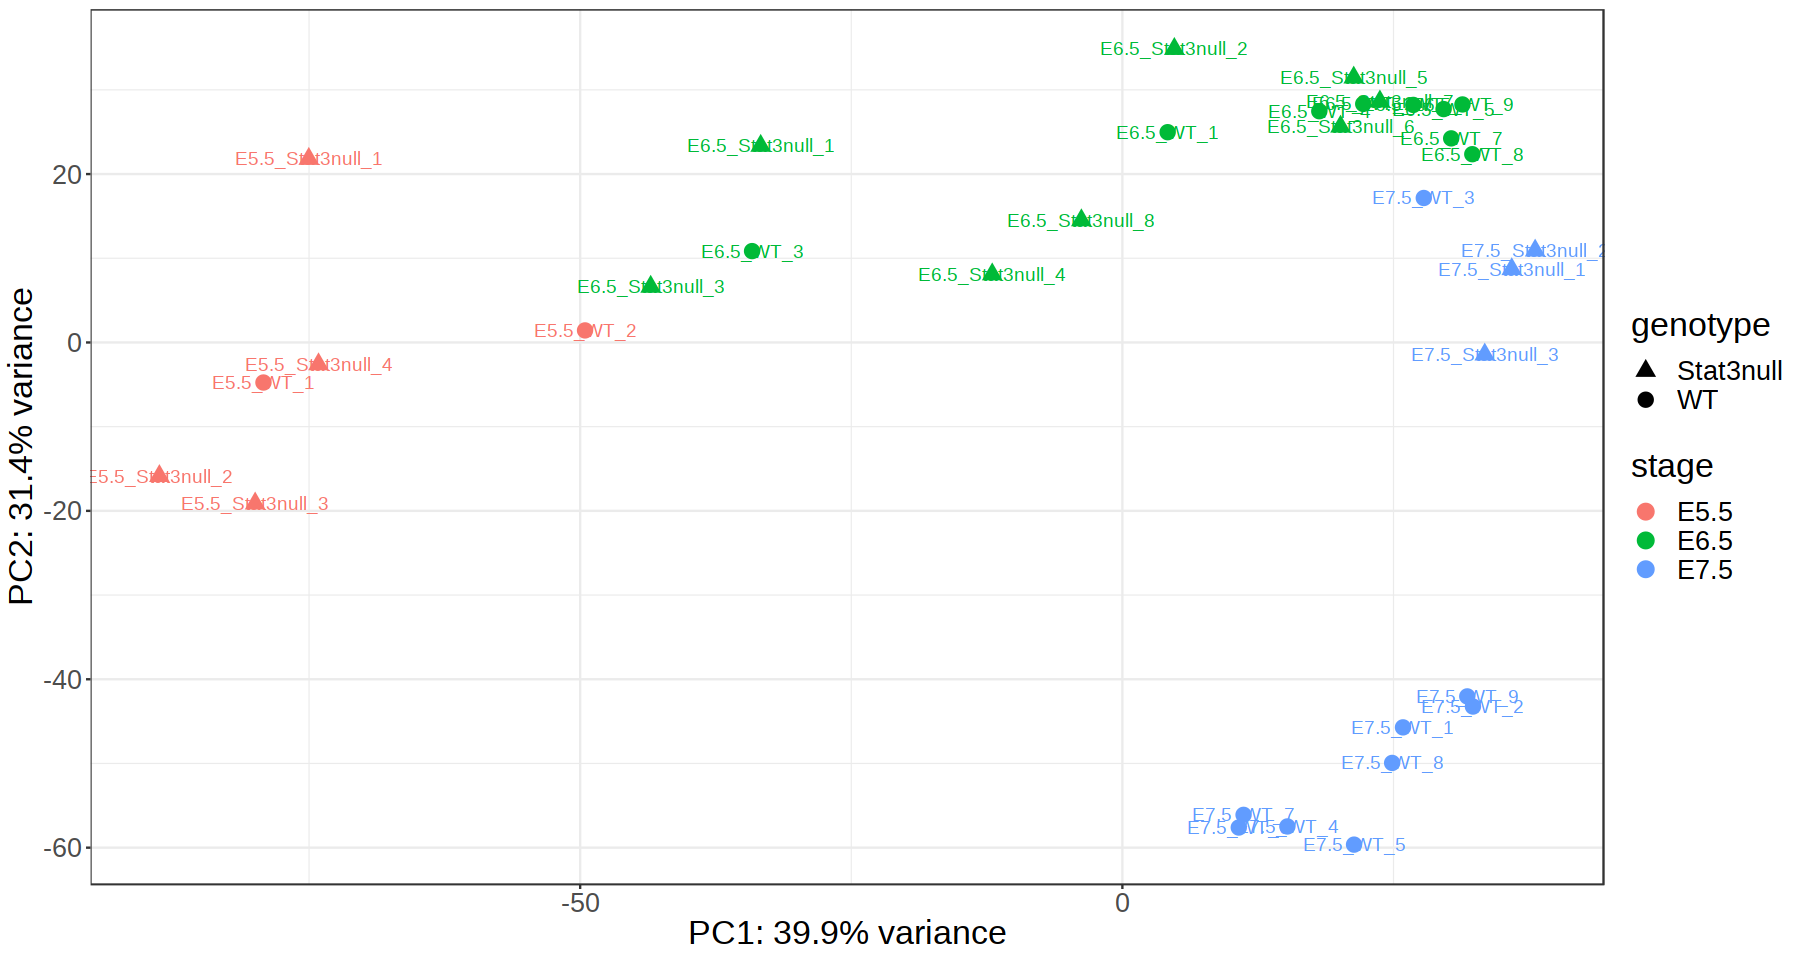

In [43]:
# Select variable genes
var_genes = genes[order(-var), gene] %>% head(5000)

# PCA 
pca = prcomp(t(as.matrix(normalized_counts[var_genes,])), scale=TRUE) # Does scale need to be TRUE?
meta_pca = cbind(meta_sample, pca$x)


options(repr.plot.width=15, repr.plot.height=8) 

# Plot
ggplot(meta_pca, aes(PC1, PC2, col=stage, shape=genotype)) + 
    scale_shape_manual(values=c('Stat3null'=17, 'WT'=16))+
    geom_point(size=4) +
    geom_text(label=rownames(meta_pca)) +
    theme_bw() + 
    labs(x = paste0('PC1: ', round(pca$sdev[1],1), '% variance'),
         y =  paste0('PC2: ', round(pca$sdev[2],1), '% variance')) + 
    theme(text=element_text(size=20, color='black'))

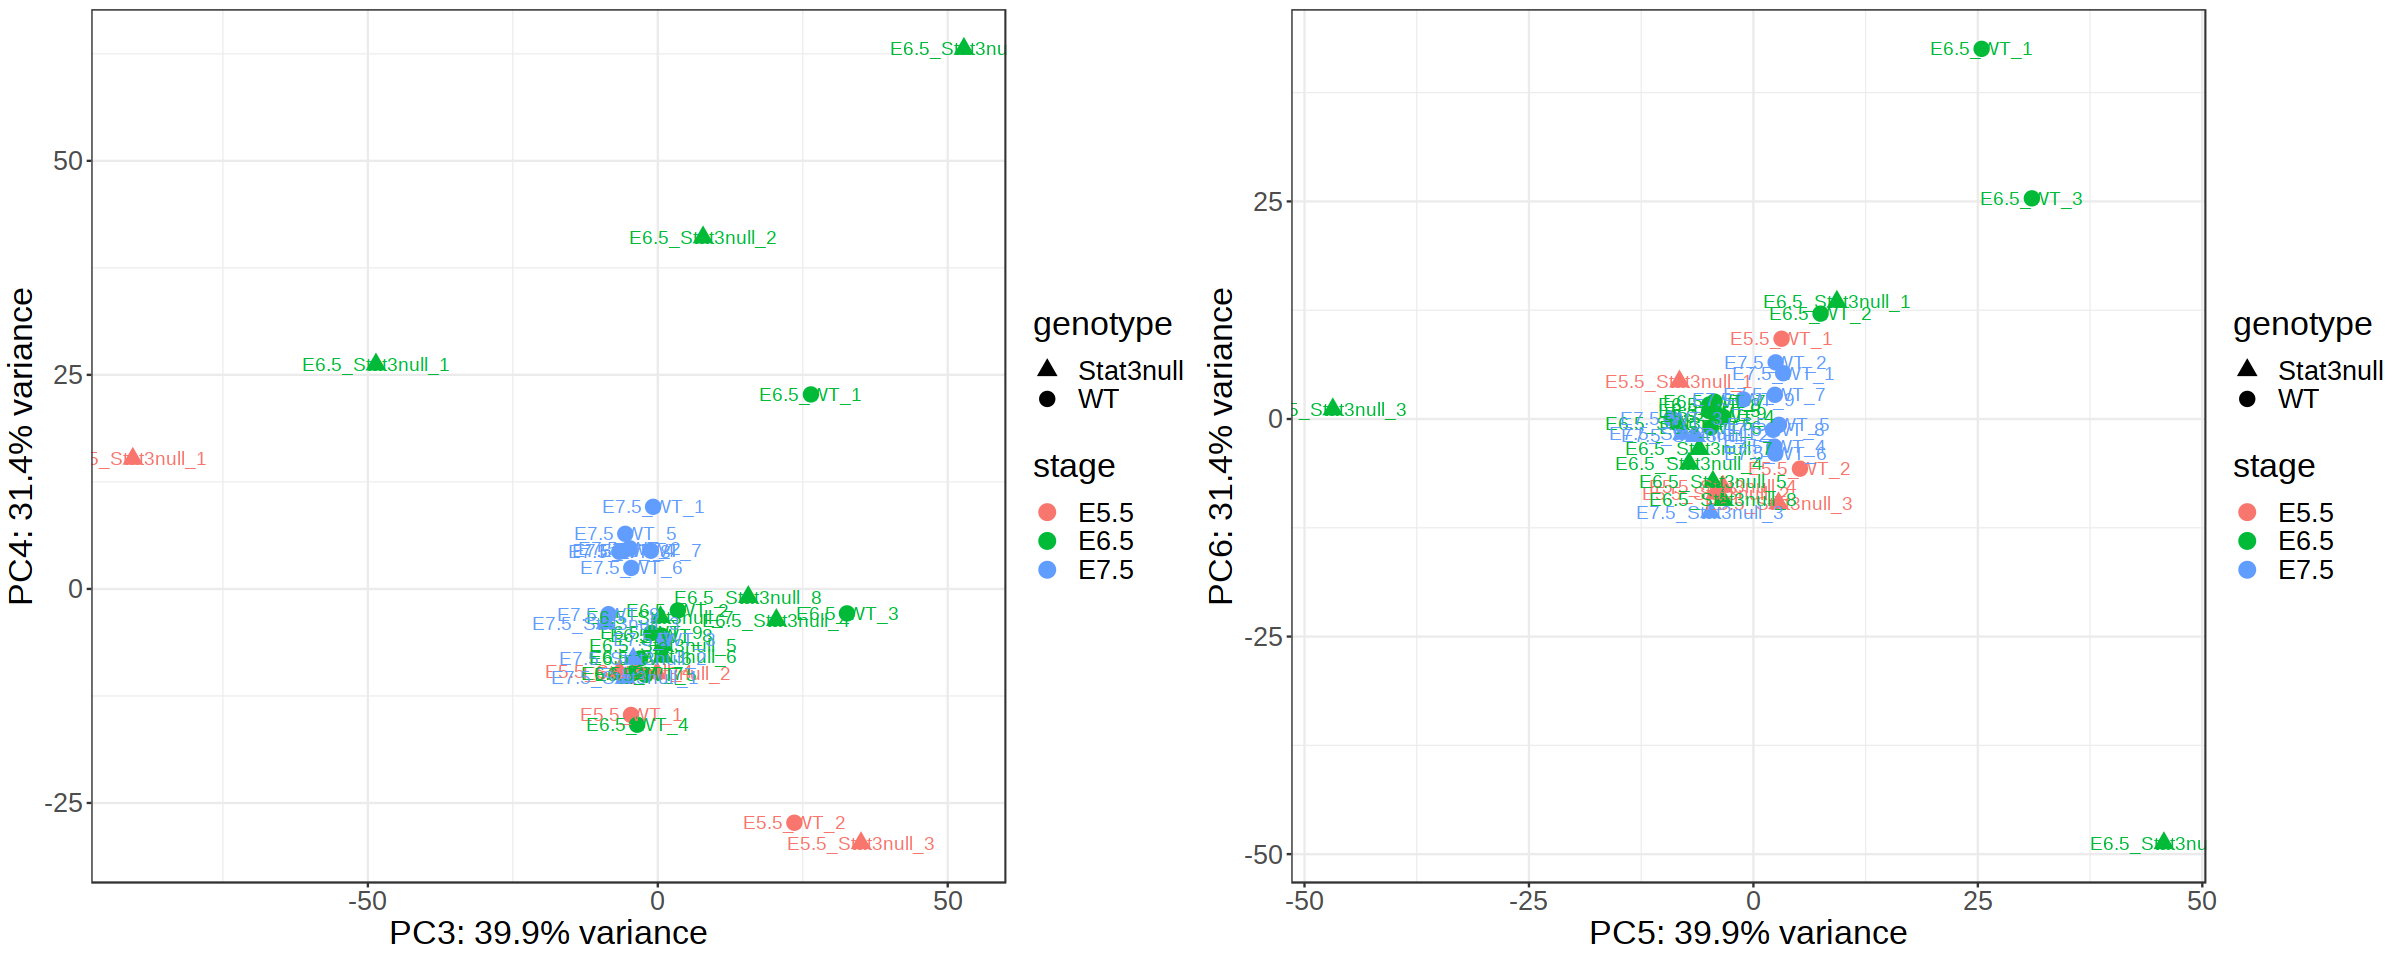

In [44]:
options(repr.plot.width=20, repr.plot.height=8) 

# Plot
ggarrange(
ggplot(meta_pca, aes(PC3, PC4, col=stage, shape=genotype)) + 
    scale_shape_manual(values=c('Stat3null'=17, 'WT'=16))+
    geom_point(size=4) +
    geom_text(label=rownames(meta_pca)) +
    theme_bw() + 
    labs(x = paste0('PC3: ', round(pca$sdev[1],1), '% variance'),
         y =  paste0('PC4: ', round(pca$sdev[2],1), '% variance')) + 
    theme(text=element_text(size=20, color='black')),
ggplot(meta_pca, aes(PC5, PC6, col=stage, shape=genotype)) + 
    scale_shape_manual(values=c('Stat3null'=17, 'WT'=16))+
    geom_point(size=4) +
    geom_text(label=rownames(meta_pca)) +
    theme_bw() + 
    labs(x = paste0('PC5: ', round(pca$sdev[1],1), '% variance'),
         y =  paste0('PC6: ', round(pca$sdev[2],1), '% variance')) + 
    theme(text=element_text(size=20, color='black'))
)

# DEG heatmap

In [49]:
# DEseq per stage
DEgenes = lapply(unique(colE567$stage), function(x){ # only on first one as test
  meta = colE567[colE567$stage == x,]
  counts.mtx = countDataE567[, rownames(meta)]
# remove non-expressed genes to get higher p values
  counts.mtx = counts.mtx[rowSums(counts.mtx) > 10, ]
  dds = DESeqDataSetFromMatrix(countData = counts.mtx, colData = meta, design = ~ genotype)  # group
  dds$genotype <- factor(dds$genotype, levels = c("WT","Stat3null"))

  deseq = DESeq(dds)
  res = results(deseq, contrast = c('genotype', "Stat3null", "WT")) %>% 
                as.data.table(., keep.rownames=T) %>% 
                setnames('rn', 'gene') %>%
                .[, sig:=padj <= padj_thr & abs(log2FoldChange) >= LFC_thr & !is.na(padj)] %>%
                .[, stage:=x]
  return(res)
}) 

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 2776 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1028 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved

In [50]:
to.plot = rbindlist(DEgenes)

In [51]:
head(to.plot)

gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,sig,stage
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
Xkr4,15.456316,-1.417724,1.526283,-0.9288733,0.3529548,0.9999888,FALSE,E5.5
Gm37329,5.367408,5.355015,3.586785,1.4929850,0.1354411,NA,FALSE,E5.5
Gm38148,10.341101,1.949333,2.615831,0.7452060,0.4561472,0.9999888,FALSE,E5.5
Gm37180,25.852359,2.431792,2.412279,1.0080894,0.3134116,0.9999888,FALSE,E5.5
Gm37363,12.724746,2.529839,2.519597,1.0040649,0.3153473,0.9999888,FALSE,E5.5
Gm7341,3.031157,-2.098420,3.351590,-0.6260968,0.5312515,NA,FALSE,E5.5


In [52]:
opts = list()
opts$nclust = 5
opts$nclust_sample = 5

In [53]:
ddsFullE567

class: DESeqDataSet 
dim: 28772 35 
metadata(1): version
assays(1): counts
rownames(28772): Xkr4 Gm18956 ... Gm29368 Gm29217
rowData names(0):
colnames(35): E5.5_Stat3null_1 E5.5_Stat3null_2 ... E7.5_WT_8 E7.5_WT_9
colData names(5): stage genotype cluster group sizeFactor

In [54]:
# get normalized counts of genes that are significant in any of the timepoints
heatmap.mtx = normalized_counts[unique(to.plot[sig==TRUE, gene]), ]

heatmap_scaled.mtx <- t(scale(t(heatmap.mtx)))

# Gene split
#perform k-means with 4 centers and take a look at the gene-to-cluster assignment.
set.seed(1234)
kclus <- kmeans(heatmap_scaled.mtx, opts$nclust)
#use the split parameter of Heatmap() in order to split the heatmap based on the k-means result:
split <- paste0("Cluster ", kclus$cluster)
# fix order of the clusters to have 1 to 4, top to bottom
split <- factor(split, levels = paste0('Cluster ', 1:opts$nclust))

# Sample split
#perform k-means with 4 centers and take a look at the gene-to-cluster assignment.
set.seed(1234)
kclus <- kmeans(t(heatmap_scaled.mtx), opts$nclust_sample)
#use the split parameter of Heatmap() in order to split the heatmap based on the k-means result:
sample_split <- paste0("Cluster ", kclus$cluster)
# fix order of the clusters to have 1 to 4, top to bottom
sample_split <- factor(sample_split, levels = paste0('Cluster ', 1:opts$nclust_sample))
    
list = c("T", "Axin2", "Cer1", "Dkk1","Wnt3a", "Tbx3","Wnt6", "Wnt8a","Wnt5a", "Igf2", "Bmp2","Bmp4", "Bmp5", "Fgf5", "Fgf3","Fgf8", "Cer1", "Prdm1", "Nkx1-2", "Cubn", "Apoe1", "Spry4", "Tead1","Apob", "Id1","Apoa1", "Apoa4" , "Sox7", "Eomes", "Hoxb2", "Hoxb3","Gbx2", "Nodal", "Notch1", "Nanog", "Esrrb", "Tfcp2l1", "Meox1", "Meox2", "Meis1", "Meis2")
genelabs <- rowAnnotation(Genes = anno_mark(at=which(rownames(heatmap_scaled.mtx) %in% list), labels = rownames(heatmap_scaled.mtx)[which(rownames(heatmap_scaled.mtx) %in% list)]))


#top annotation
anno <- HeatmapAnnotation(df=colData(ddsFullE567)[, c("genotype", "stage")], 
                          col = list(genotype=c("WT"="#00afbb", "Stat3null"="#fc4e07"), 
                                     stage=c("E5.5"="#66cc33", "E6.5"="#cc9933", "E7.5"="#3399cc")),
                          annotation_legend_param = list(title_gp = gpar(fontsize = 12),
                                                         labels_gp = gpar(fontsize = 12)))


hm <- Heatmap(heatmap_scaled.mtx, 
              split = split, 
              name = "z-score", 
              top_annotation = anno,
            #  cluster_row_slices = FALSE, 
              cluster_rows = TRUE,
              column_split = sample_split, 
              cluster_columns = TRUE,
              show_row_dend = FALSE, 
              row_gap = unit(1, "mm"), 
              column_gap = unit(1, "mm"), 
              border = TRUE, 
              row_title_gp = gpar(fontsize = 12),
              row_names_gp = gpar(fontsize = 10), 
              column_title_gp = gpar(fontsize = 12), 
              column_names_gp = gpar(fontsize = 10),
              heatmap_legend_param = list(title_gp=gpar(fontsize = 12),
                                          labels_gp=gpar(fontsize = 12)
                                          )
              )


png 
  2

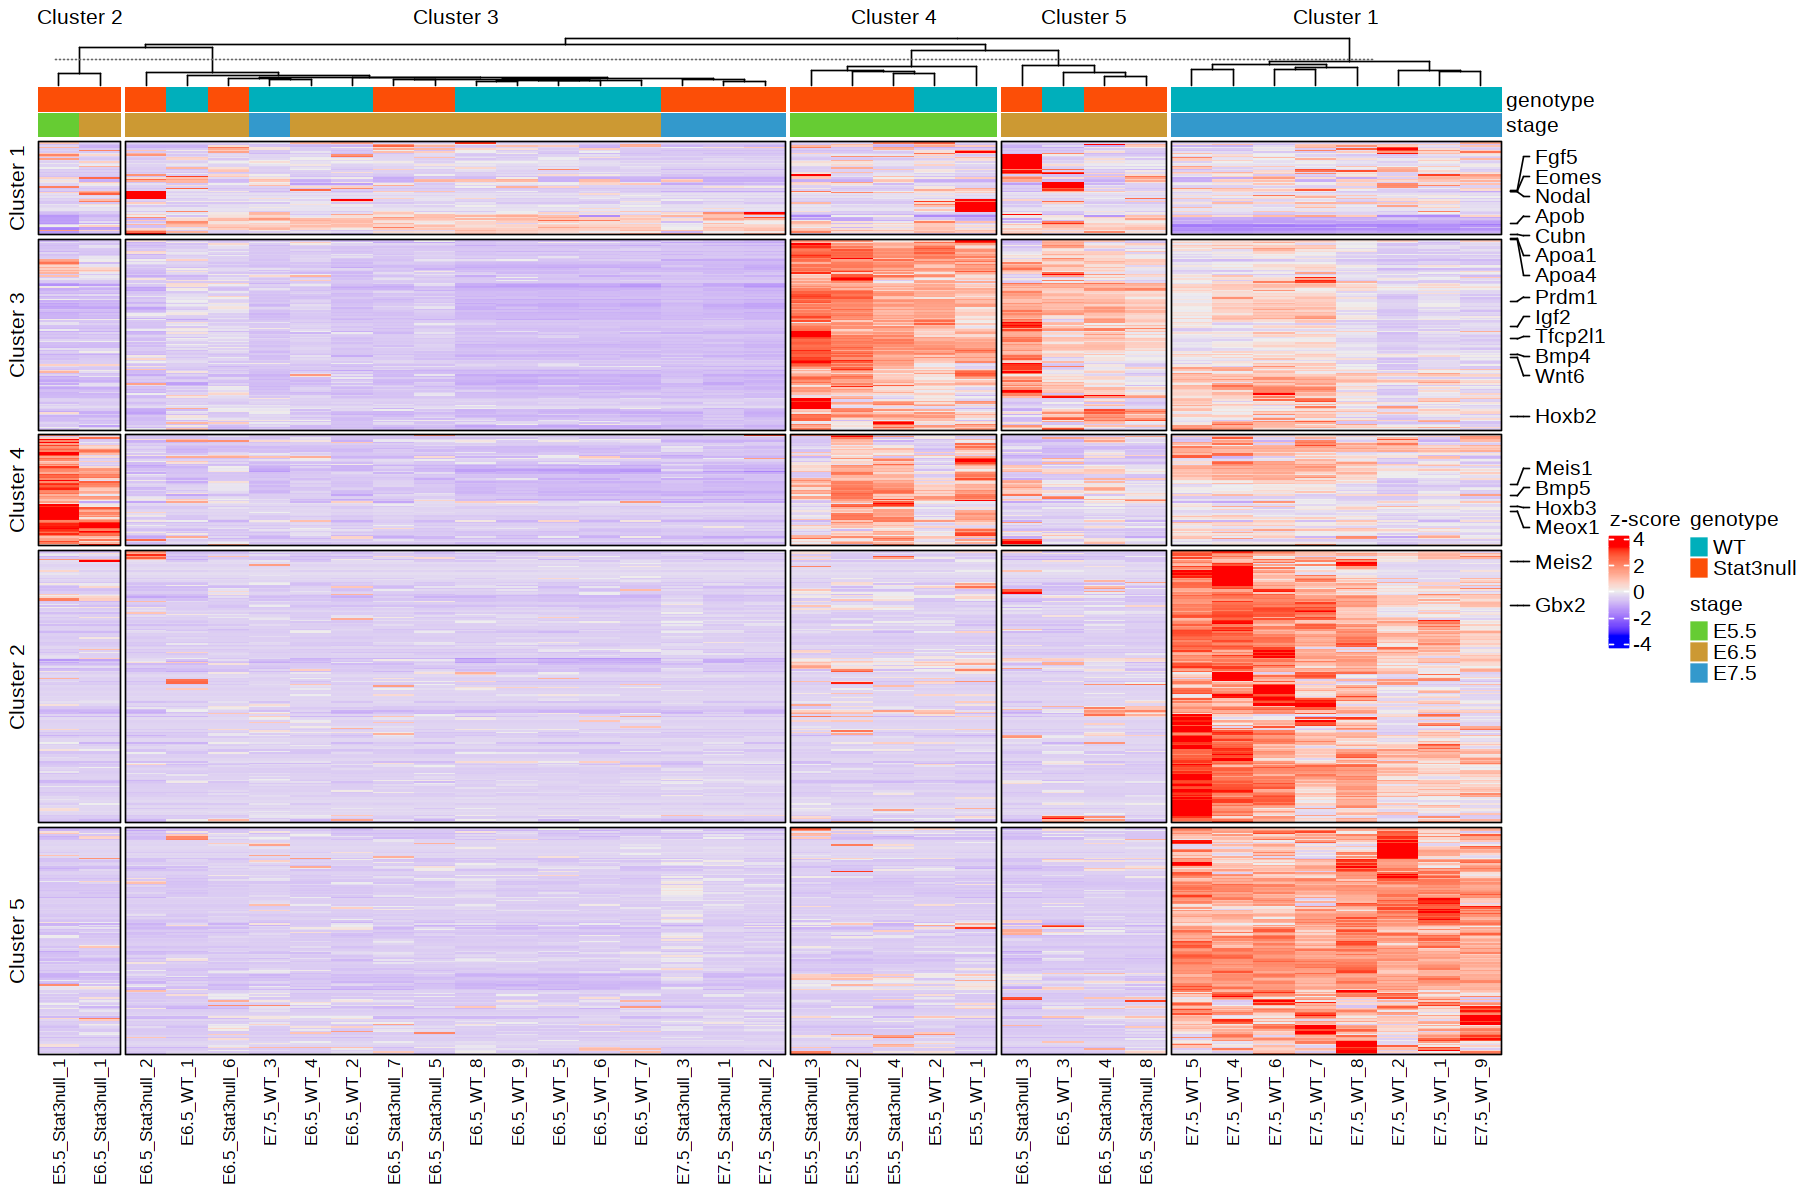

In [55]:
pdf("Heatmap100522_c5.pdf", width = 7.5, height = 10)
draw(hm + genelabs)
dev.off()
    
options(repr.plot.width=15, repr.plot.height=10) 
draw(hm + genelabs)

# Clusters on PCA

#### As you can see, the clusters don't separate the E6.5 WT by the ones we exclude or keep. We need more convincing arguments to exclude them

In [56]:
opts$nclust = 8
# get normalized counts of genes that are significant in any of the timepoints
heatmap.mtx = normalized_counts[var_genes,]

heatmap_scaled.mtx <- t(scale(t(heatmap.mtx)))

#perform k-means with 4 centers and take a look at the gene-to-cluster assignment.
set.seed(1234)
kclus <- kmeans(t(heatmap_scaled.mtx), opts$nclust)


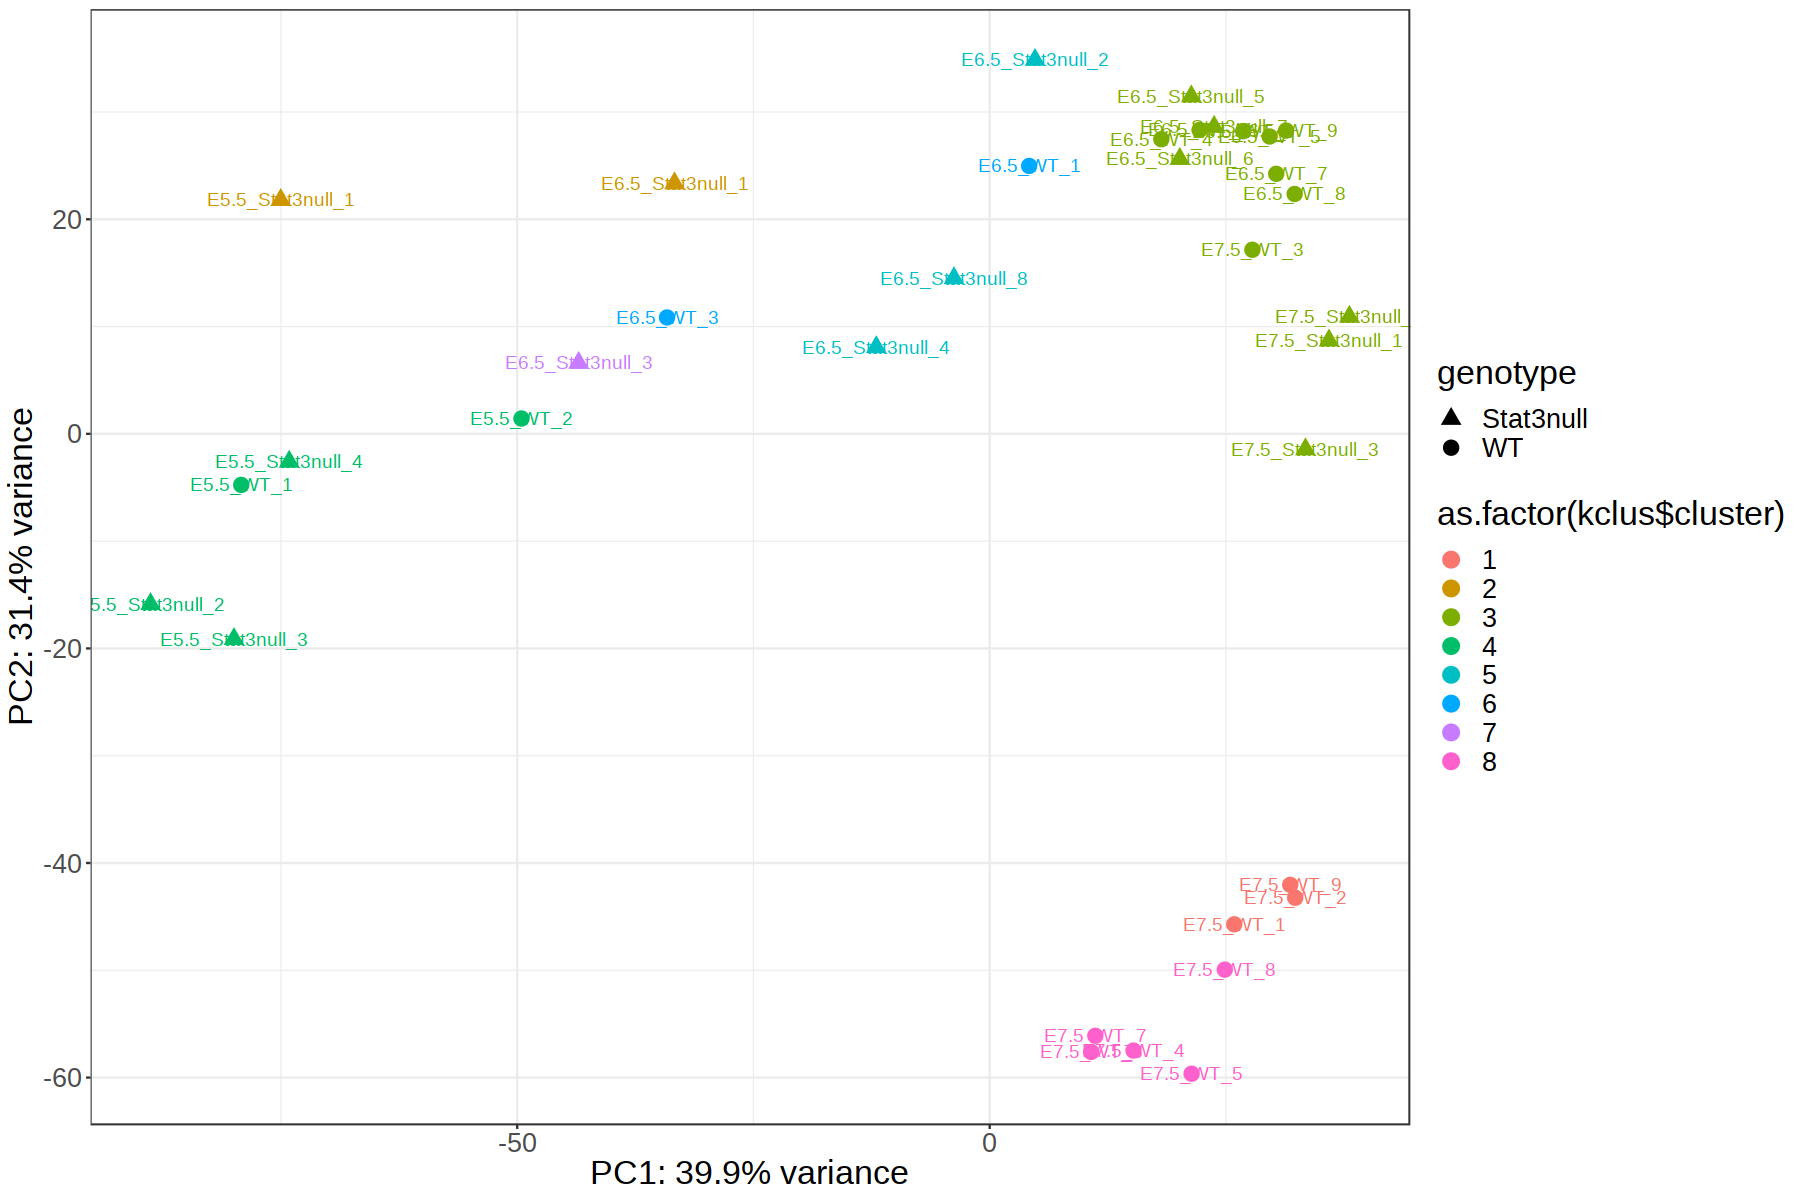

In [57]:

# Plot
ggplot(meta_pca, aes(PC1, PC2, col=as.factor(kclus$cluster), shape=genotype)) + 
    scale_shape_manual(values=c('Stat3null'=17, 'WT'=16))+
    geom_point(size=4) +
    geom_text(label=rownames(meta_pca)) +
    theme_bw() + 
    labs(x = paste0('PC1: ', round(pca$sdev[1],1), '% variance'),
         y =  paste0('PC2: ', round(pca$sdev[2],1), '% variance')) + 
    theme(text=element_text(size=20, color='black'))